# Burst Analysis Quickstart: stimRemovalNull well0 DIV12

This notebook focuses on a single `stimRemovalNull` recording for burst-analysis prototyping. For now it:

- loads `well0 / DIV12`
- selects reference electrodes using the usual `PrepConfig`
- shows the initial layout-grid and pooled IFR views via the standard `ephax` analyzers
- computes per-electrode instantaneous firing-rate (IFR) traces on a shared time grid
- visualises the electrode-resolved IFR matrix and the population-average firing rate
- identifies first-pass burst anchors from the collective firing trace for later alignment work


In [437]:
%matplotlib inline

import os
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import imageio.v2 as imageio

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str((repo_root / ".mpl-cache").resolve()))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext, LogLocator
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_prominences
from IPython.display import Image, display

from ephax import RestingActivityDataset, PrepConfig, LayoutGridPlotter
from ephax.analyzers import IFRAnalyzer
from ephax.analyzers.ifr import IFRConfig
from ephax.helper_functions import calculate_ifr

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)


## Configure Recording and Burst View

The defaults below mirror the existing quickstart style: a 300 s recording-relative window and top-active electrode selection.


In [ ]:
WELL = 0
DIV = 14
DATA_SUBPATH = Path(f"ephax/data/stimRemovalNull/well{WELL}/DIV{DIV}_240703_data_well{WELL}_exp_data.npz")

START_SEC = 0.0
END_SEC = 300.0
MIN_AMP = 0.0

TOP_START = 0
TOP_STOP = 300

IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15

BURST_MIN_DISTANCE_SEC = 1.0
BURST_PROMINENCE_QUANTILE = 0.90
BURST_PROMINENCE_SCALE = 0.20
BURST_WINDOW_SEC = 2.5

COARSE_EPOCH_REL_HEIGHT = 0.20
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
GAMMA_SEARCH_MS = 120.0
GAMMA_SEARCH_TO_EPOCH_END = True
GAMMA_MIN_DISTANCE_MS = 5.0
GAMMA_PROMINENCE_FRAC = 0.08
GAMMA_PROMINENCE_ABS_FLOOR = 0.10
GAMMA_KEEP_HEIGHT_FRAC = 0.50
ALIGN_PRE_MS = 20.0
ALIGN_POST_MS = 40.0
SORT_PEAK_PRE_MS = 5.0
SORT_PEAK_POST_MS = 10.0
GIF_FRAME_STEP_MS = 2.0
EXAMPLE_GAMMA_EVENT_COUNT = 6
GIF_OUTPUT_PATH = Path(f"GIFs/stimRemovalNull_well{WELL}_DIV{DIV}_gamma_ifr_grid.gif")
HEX_GRID_SIZE = 25

npz_path = repo_root / DATA_SUBPATH
if not npz_path.exists():
    raise FileNotFoundError(f"Could not find recording file: {npz_path}")

npz_path


PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/ephax/data/stimRemovalNull/well0/DIV14_240703_data_well0_exp_data.npz')

In [439]:
with np.load(npz_path, allow_pickle=True) as data:
    sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
    frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
    rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0

file_info = [(str(npz_path), rec_t0 + START_SEC, rec_t0 + END_SEC, 0)]
ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=MIN_AMP)
rec = ds.recordings[0]

in_window = (rec.spikes["time"] >= rec.start_time) & (rec.spikes["time"] <= rec.end_time)
duration = float(rec.end_time - rec.start_time)
n_spikes = int(np.sum(in_window))
n_active_electrodes = int(np.unique(rec.spikes["electrode"][in_window]).size)

print(f"Loaded 1 recording from {npz_path.name}")
print(f"Window: [{rec.start_time:.4f}, {rec.end_time:.4f}] s ({duration:.1f} s)")
print(f"Sampling rate: {rec.sf:.1f} Hz | spikes in window: {n_spikes:,} | active electrodes in window: {n_active_electrodes}")


Loaded 1 recording from DIV14_240703_data_well0_exp_data.npz
Window: [-0.2236, 299.7764] s (300.0 s)
Sampling rate: 10000.0 Hz | spikes in window: 129,768 | active electrodes in window: 1007


## Select Reference Electrodes

Use the same `PrepConfig` pattern as elsewhere in the repo, then keep the selected electrodes fixed for the burst analysis steps below.


In [440]:
prep_cfg = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)
refs = ds.select_ref_electrodes(prep_cfg)[0]

print(f"Selected {refs.size} electrodes")
print("First 20 selected electrode ids:", refs[:20])


Selected 300 electrodes
First 20 selected electrode ids: [ 6945 21815   869  4795  7763 23287  8629  5247 18765  6117 24429 20963
 20637 17459  7891 13889  8635 20491 22297 15653]


## Initial Layout and IFRAnalyzer Views

Before the burst-specific plots below, reuse the standard `ephax` visualizers on the same single-recording dataset and `PrepConfig` selection.


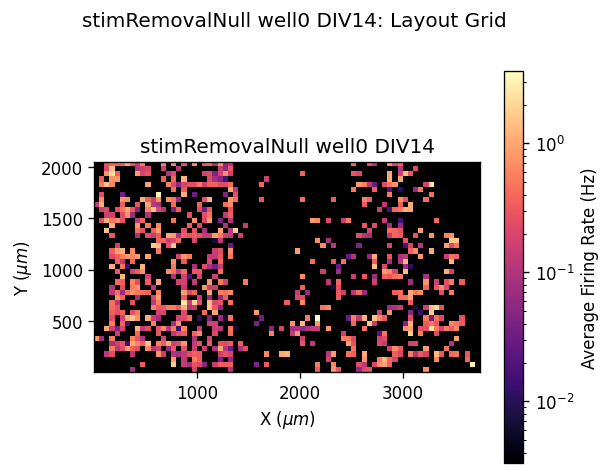

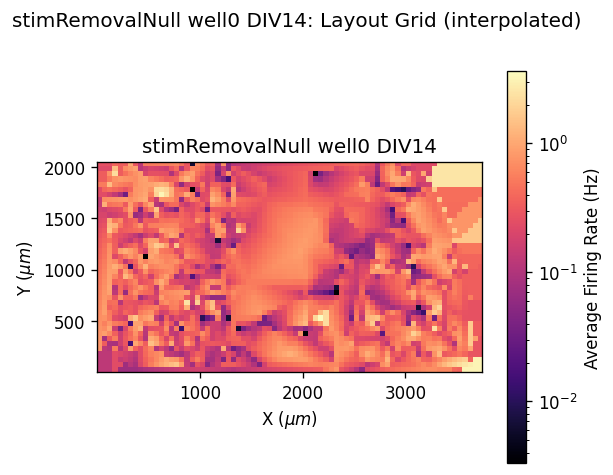

Collected 170574 IFR samples
GMM peak locations (Hz): [2.000e-02 7.000e-02 1.240e+00 3.293e+01]


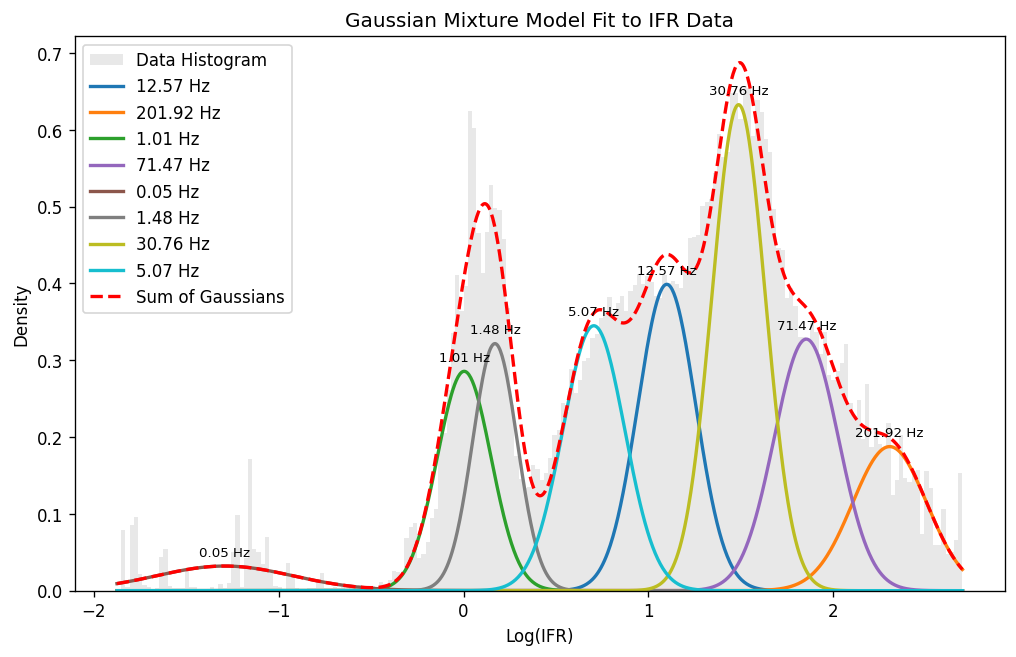

[(<Figure size 1440x960 with 3 Axes>,
  (<Axes: title={'center': 'stimRemovalNull well0 DIV14: IFRAnalyzer | stimRemovalNull well0 DIV14: Log Instantaneous Firing Rate Across Top 300 electrodes'}, xlabel='Time (s)', ylabel='Channel by Firing Frequency Rank'>,
   <Axes: title={'center': 'Histogram of Instantaneous Firing Rates'}, xlabel='Log Instantaneous Firing Rate (Hz)', ylabel='Frequency'>))]

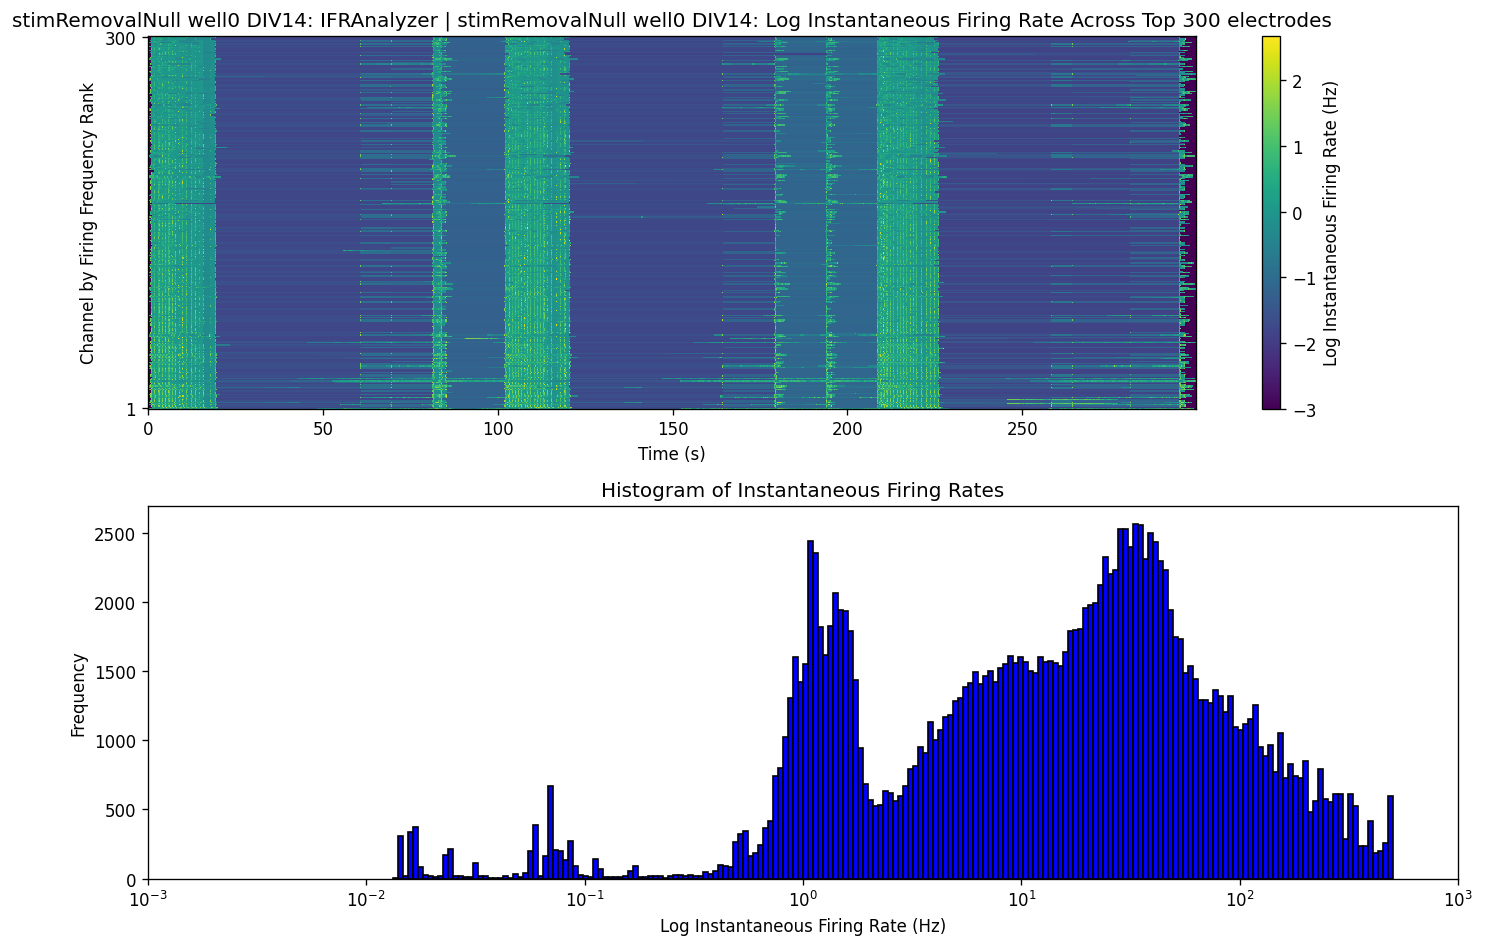

In [441]:
recording_labels = [f"stimRemovalNull well{WELL} DIV{DIV}"]

lg = LayoutGridPlotter(ds)
lg.plot_grid_avghz_panel(
    grid_size=50.0,
    ncols=1,
    interpolate=False,
    title=f"stimRemovalNull well{WELL} DIV{DIV}: Layout Grid",
    recording_titles=recording_labels,
)
lg.plot_grid_avghz_panel(
    grid_size=50.0,
    ncols=1,
    interpolate=True,
    title=f"stimRemovalNull well{WELL} DIV{DIV}: Layout Grid (interpolated)",
    recording_titles=recording_labels,
)

ifr_hist_bins = 200
ifr_cfg = IFRConfig(
    log_scale=True,
    overlay_gmm=True,
    ts_bins=200,
    time_grid_hz=200.0,
    max_time_points=2_000,
)
ifr_analyzer = IFRAnalyzer.from_dataset(ds, config=ifr_cfg, selection_prep_config=prep_cfg)
peaks = ifr_analyzer.peaks()

print(f"Collected {peaks.values.size} IFR samples")
if peaks.peaks_hz.size:
    print("GMM peak locations (Hz):", np.round(peaks.peaks_hz, 2))
else:
    print("No IFR peaks detected; consider widening the selection window.")

ifr_analyzer.plot_histogram(hist_bins=ifr_hist_bins, show=True)
ifr_analyzer.plot_timeseries(
    recording_titles=recording_labels,
    title=f"stimRemovalNull well{WELL} DIV{DIV}: IFRAnalyzer",
)


## Build a Shared IFR Matrix

Each selected electrode gets interpolated onto the same time grid. The burst population trace is the pointwise mean across the selected electrodes.


In [442]:
def build_population_ifr(recording, selected_electrodes, grid_hz=50.0, smooth_sigma_sec=0.15):
    ifr_data, per_electrode_mean_hz, _ = calculate_ifr(
        recording.spikes,
        selected_electrodes,
        recording.start_time,
        recording.end_time,
    )

    dt = 1.0 / float(grid_hz)
    time_grid = np.arange(recording.start_time, recording.end_time, dt, dtype=float)

    traces = []
    electrodes = []
    avg_rates = []
    for el in np.asarray(selected_electrodes, dtype=int):
        if int(el) not in ifr_data:
            continue
        times, values = ifr_data[int(el)]
        traces.append(np.interp(time_grid, times, values))
        electrodes.append(int(el))
        avg_rates.append(float(per_electrode_mean_hz[int(el)]))

    if not traces:
        raise ValueError("No IFR traces were produced for the selected electrodes.")

    ifr_matrix = np.asarray(traces, dtype=float)
    mean_ifr = ifr_matrix.mean(axis=0)
    sigma_bins = max(float(smooth_sigma_sec) * float(grid_hz), 1e-6)
    mean_ifr_smooth = gaussian_filter1d(mean_ifr, sigma=sigma_bins, mode="nearest")

    return {
        "time_grid": time_grid,
        "electrodes": np.asarray(electrodes, dtype=int),
        "ifr_matrix": ifr_matrix,
        "mean_ifr": mean_ifr,
        "mean_ifr_smooth": mean_ifr_smooth,
        "per_electrode_mean_hz": np.asarray(avg_rates, dtype=float),
    }


burst_data = build_population_ifr(
    rec,
    refs,
    grid_hz=IFR_GRID_HZ,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
)

time_grid = burst_data["time_grid"]
ifr_matrix = burst_data["ifr_matrix"]
mean_ifr = burst_data["mean_ifr"]
mean_ifr_smooth = burst_data["mean_ifr_smooth"]

positive_ifr = ifr_matrix[ifr_matrix > 0]
if positive_ifr.size == 0:
    raise ValueError("IFR matrix contains no positive values for log-scale plotting.")

heatmap_vmin = max(1e-3, float(np.quantile(positive_ifr, 0.01)))
heatmap_vmax = max(heatmap_vmin * 10.0, float(np.quantile(positive_ifr, 0.99)))
mean_log_floor = max(heatmap_vmin, 1e-3)

def plot_ifr_summary(time_axis, ifr_view, mean_view, mean_smooth_view, heatmap_title, mean_title, mean_log_scale=False):
    fig = plt.figure(figsize=(14, 8), constrained_layout=True)
    gs = fig.add_gridspec(
        2,
        2,
        height_ratios=[3.0, 1.6],
        width_ratios=[40.0, 1.6],
    )
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    cax = fig.add_subplot(gs[0, 1])
    fig.add_subplot(gs[1, 1]).axis("off")

    display_ifr = np.clip(ifr_view, heatmap_vmin, heatmap_vmax)
    im = ax0.imshow(
        display_ifr,
        aspect="auto",
        origin="lower",
        extent=[time_axis[0], time_axis[-1], 0.5, ifr_view.shape[0] + 0.5],
        cmap="viridis",
        norm=LogNorm(vmin=heatmap_vmin, vmax=heatmap_vmax),
    )
    ax0.set_ylabel("Selected electrode rank")
    ax0.set_yticks([1, ifr_view.shape[0]])
    ax0.set_title(heatmap_title)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Instantaneous firing rate (Hz, log scale)")
    cbar.locator = LogLocator(base=10)
    cbar.formatter = LogFormatterMathtext(base=10)
    cbar.update_ticks()

    if mean_log_scale:
        ax1.plot(time_axis, np.clip(mean_view, mean_log_floor, None), color="0.70", lw=1.0, label="Population mean IFR")
        ax1.plot(
            time_axis,
            np.clip(mean_smooth_view, mean_log_floor, None),
            color="black",
            lw=2.0,
            label=f"Smoothed mean IFR (sigma={SMOOTH_SIGMA_SEC:.2f} s)",
        )
        ax1.set_yscale("log")
        ax1.set_ylabel("Hz (log scale)")
    else:
        ax1.plot(time_axis, mean_view, color="0.70", lw=1.0, label="Population mean IFR")
        ax1.plot(
            time_axis,
            mean_smooth_view,
            color="black",
            lw=2.0,
            label=f"Smoothed mean IFR (sigma={SMOOTH_SIGMA_SEC:.2f} s)",
        )
        ax1.set_ylabel("Hz")

    ax1.set_xlabel("Time (s)")
    ax1.set_title(mean_title)
    ax1.legend(loc="upper right")
    ax1.set_xlim(float(time_axis[0]), float(time_axis[-1]))
    plt.show()

print(f"IFR matrix shape: {ifr_matrix.shape}")
print(f"Population mean range: {mean_ifr.min():.3f} to {mean_ifr.max():.3f} Hz")
print(f"Smoothed population mean range: {mean_ifr_smooth.min():.3f} to {mean_ifr_smooth.max():.3f} Hz")
print(f"Heatmap log scale range: {heatmap_vmin:.4f} to {heatmap_vmax:.4f} Hz")


IFR matrix shape: (300, 15000)
Population mean range: 0.000 to 68.094 Hz
Smoothed population mean range: 0.009 to 8.509 Hz
Heatmap log scale range: 0.0145 to 19.0114 Hz


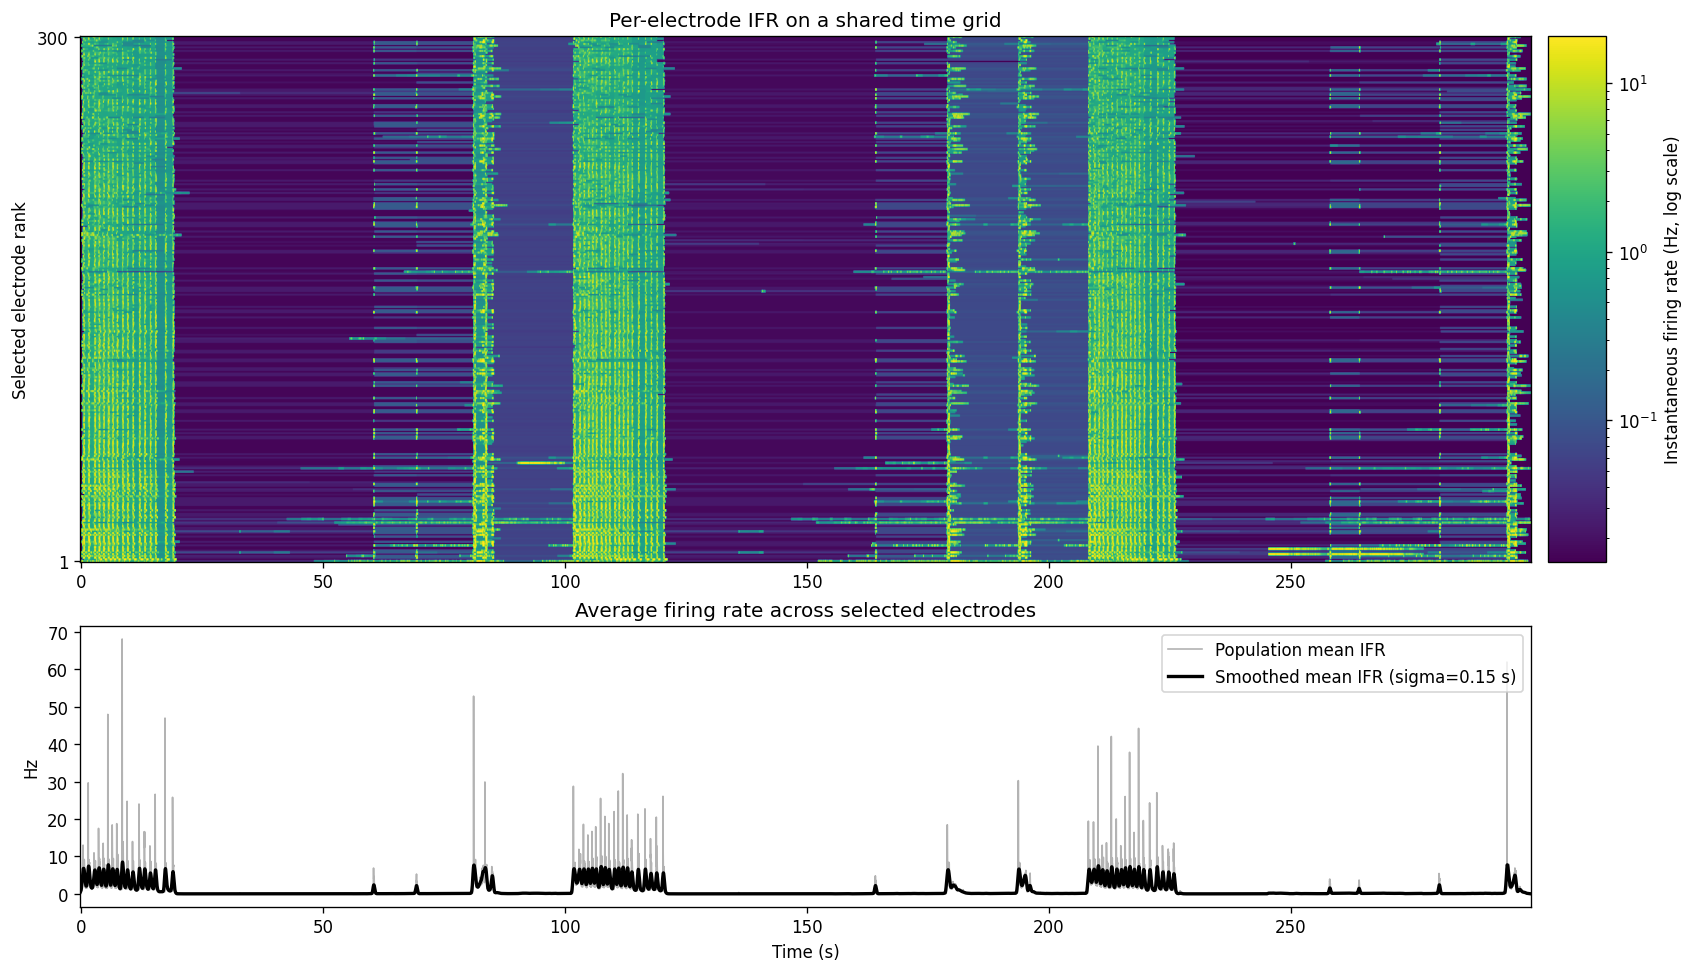

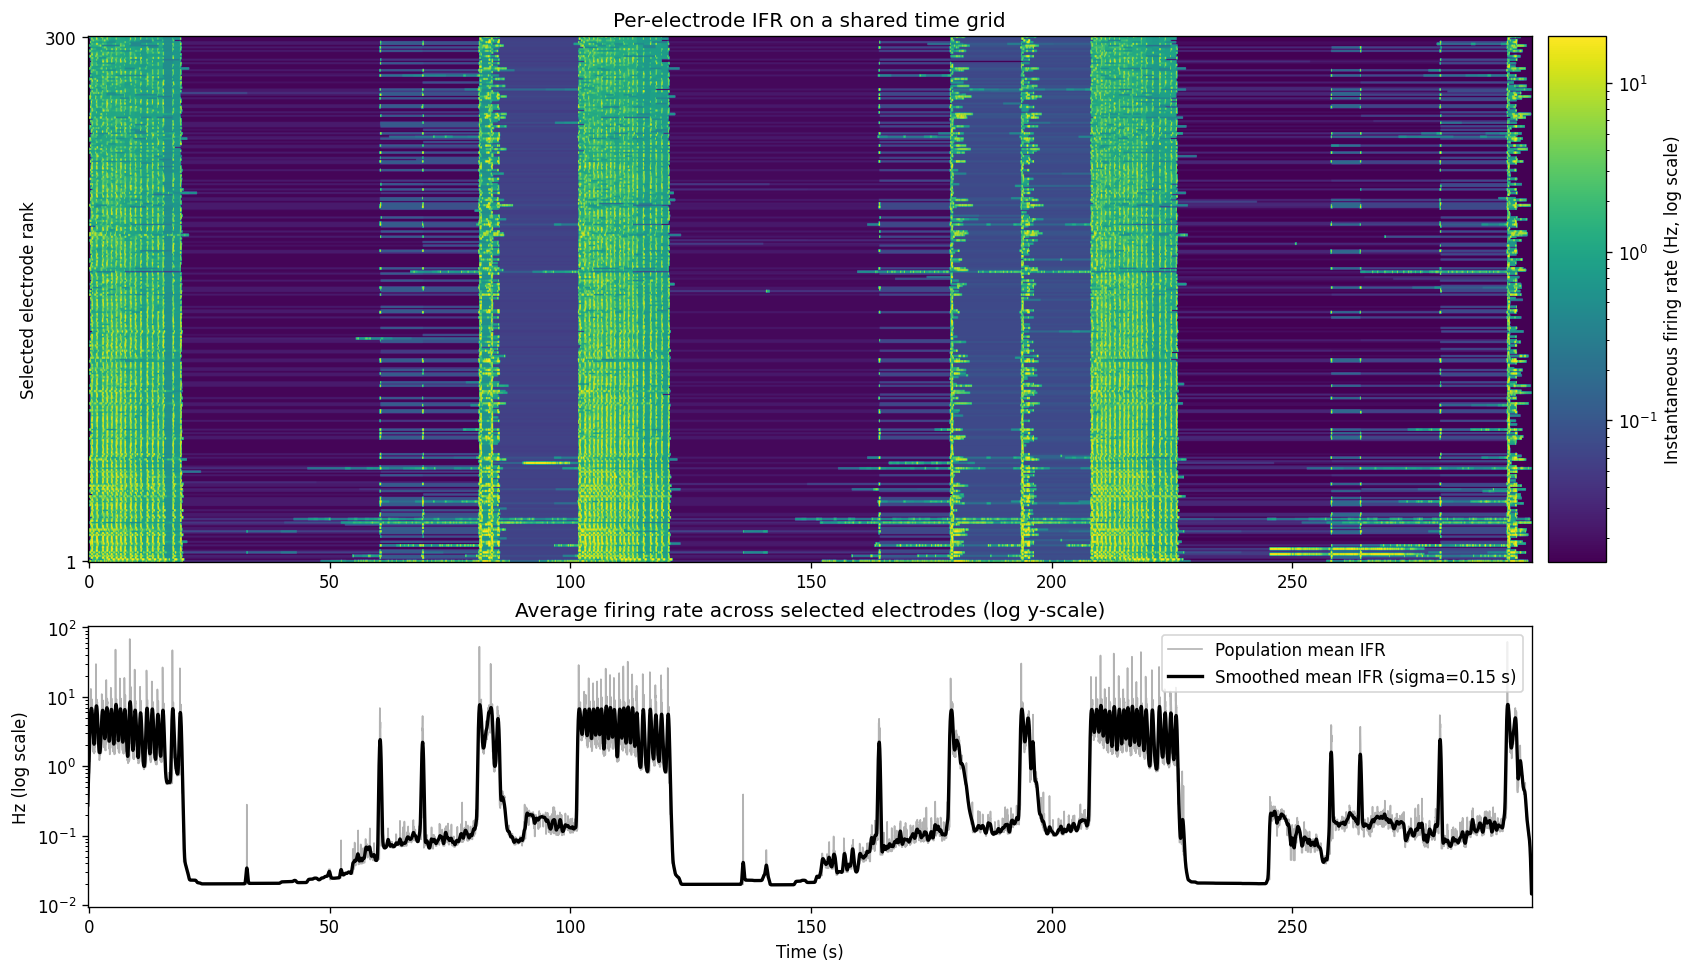

In [443]:
plot_ifr_summary(
    time_grid,
    ifr_matrix,
    mean_ifr,
    mean_ifr_smooth,
    heatmap_title="Per-electrode IFR on a shared time grid",
    mean_title="Average firing rate across selected electrodes",
    mean_log_scale=False,
)

plot_ifr_summary(
    time_grid,
    ifr_matrix,
    mean_ifr,
    mean_ifr_smooth,
    heatmap_title="Per-electrode IFR on a shared time grid",
    mean_title="Average firing rate across selected electrodes (log y-scale)",
    mean_log_scale=True,
)


## Zoom Into a High-Activity Window

The full 300 s trace is useful for context, but a short zoom makes the cross-electrode burst structure easier to inspect.


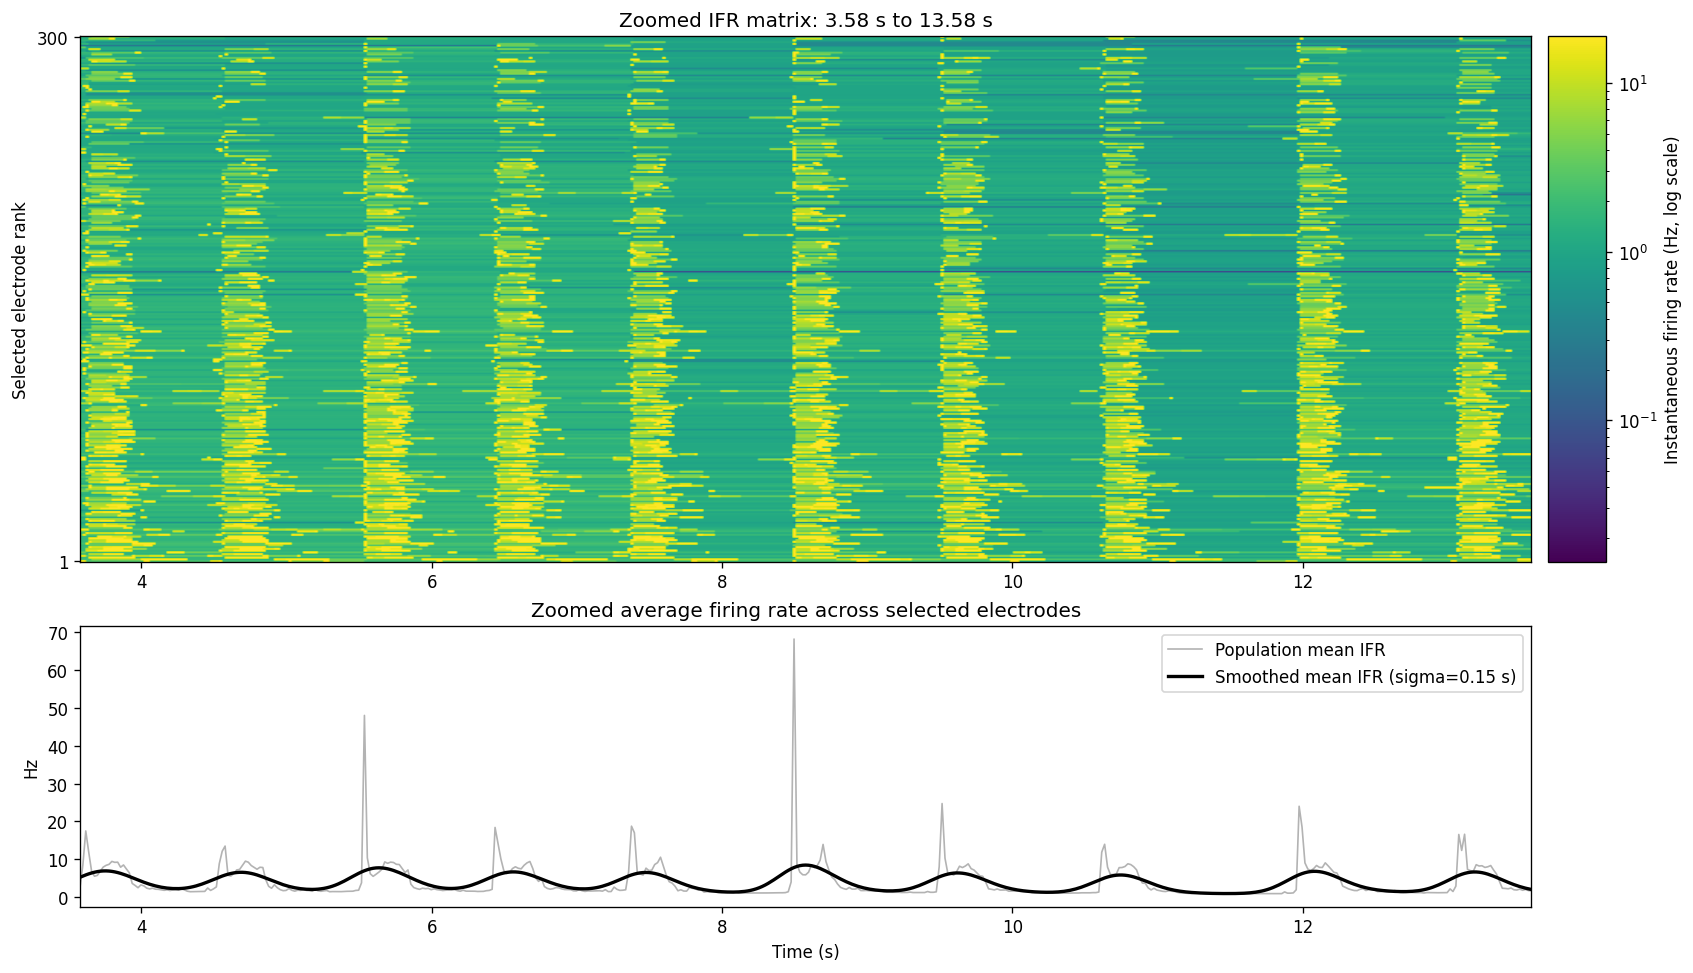

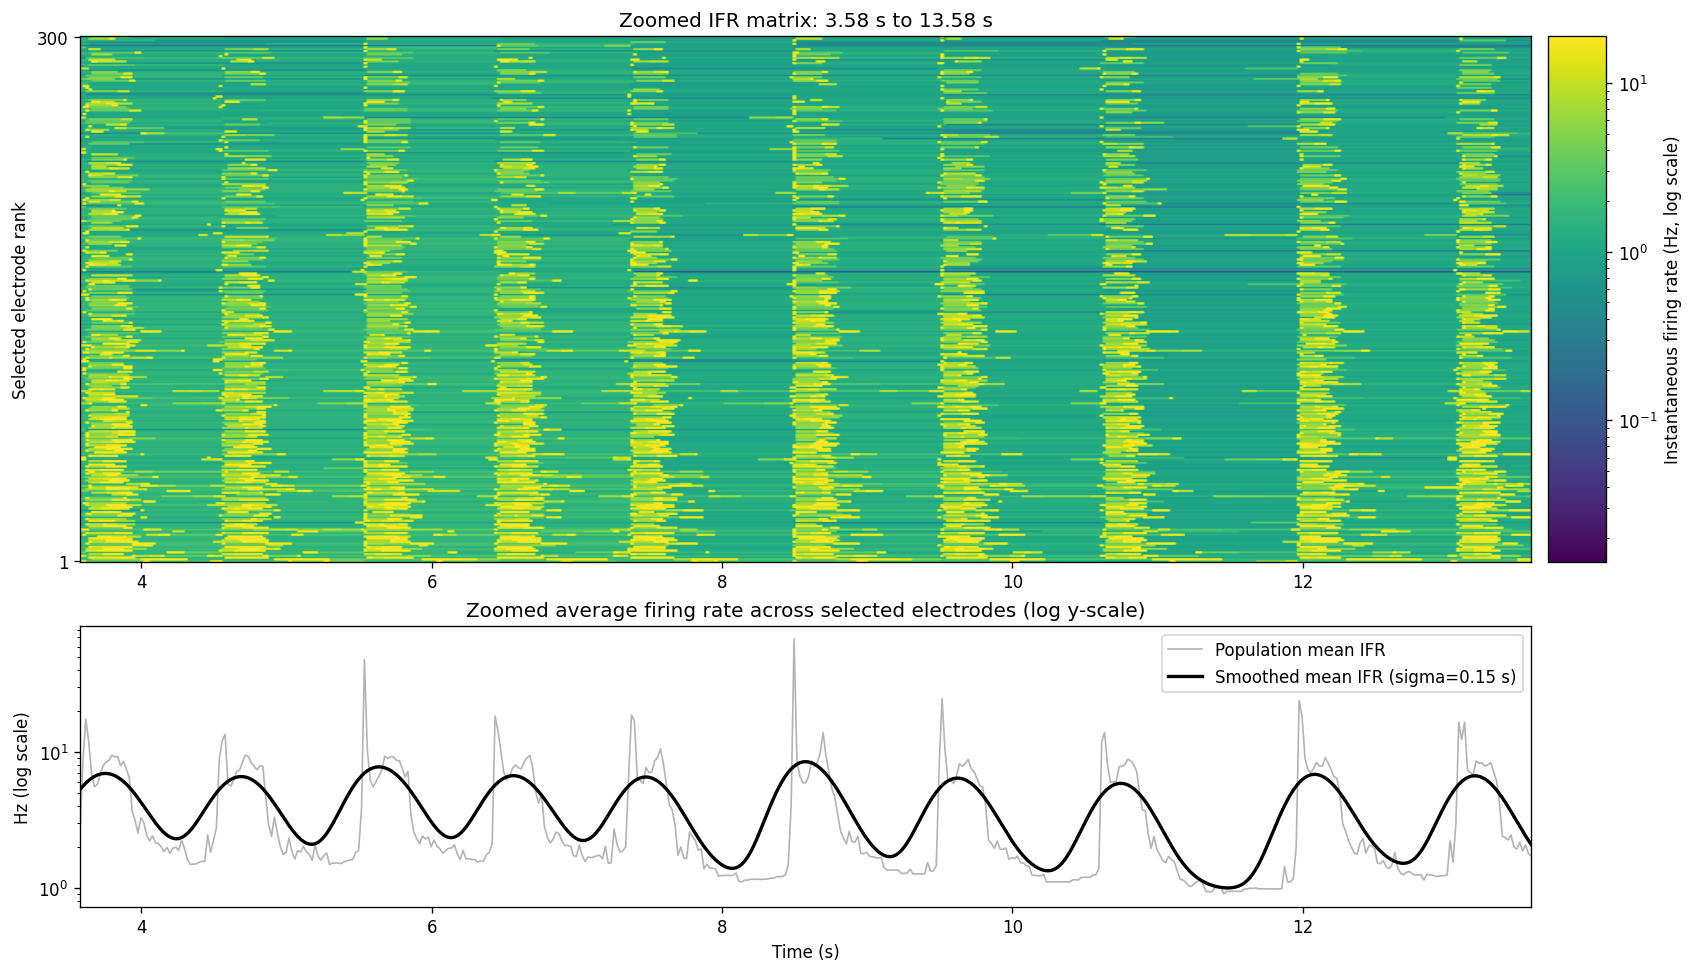

In [444]:
zoom_center_sec = float(time_grid[np.argmax(mean_ifr_smooth)])
zoom_half_width_sec = 5.0
zoom_start = max(time_grid[0], zoom_center_sec - zoom_half_width_sec)
zoom_stop = min(time_grid[-1], zoom_center_sec + zoom_half_width_sec)
zoom_mask = (time_grid >= zoom_start) & (time_grid <= zoom_stop)

plot_ifr_summary(
    time_grid[zoom_mask],
    ifr_matrix[:, zoom_mask],
    mean_ifr[zoom_mask],
    mean_ifr_smooth[zoom_mask],
    heatmap_title=f"Zoomed IFR matrix: {zoom_start:.2f} s to {zoom_stop:.2f} s",
    mean_title="Zoomed average firing rate across selected electrodes",
    mean_log_scale=False,
)

plot_ifr_summary(
    time_grid[zoom_mask],
    ifr_matrix[:, zoom_mask],
    mean_ifr[zoom_mask],
    mean_ifr_smooth[zoom_mask],
    heatmap_title=f"Zoomed IFR matrix: {zoom_start:.2f} s to {zoom_stop:.2f} s",
    mean_title="Zoomed average firing rate across selected electrodes (log y-scale)",
    mean_log_scale=True,
)


## Nested Burst and Gamma Anchors

We now separate the problem into two scales:

- a **coarse burst epoch** on the slow population IFR trace
- a **nested gamma anchor** inside that burst using a high-resolution spike-density signal

This avoids treating several slow subpeaks from the same burst as independent events.


In [445]:
def detect_coarse_burst_epochs(time_axis, slow_signal, peak_distance_sec, prominence_quantile, prominence_scale, rel_height=0.20):
    peak_distance_bins = max(1, int(round(peak_distance_sec * IFR_GRID_HZ)))
    prominence_floor = float(np.quantile(slow_signal, prominence_quantile) * prominence_scale)
    raw_peaks, peak_props = find_peaks(
        slow_signal,
        distance=peak_distance_bins,
        prominence=prominence_floor,
    )

    slow_baseline = float(np.quantile(slow_signal, 0.25))
    intervals = []
    for peak_idx in raw_peaks:
        peak_height = float(slow_signal[peak_idx])
        cutoff = slow_baseline + rel_height * (peak_height - slow_baseline)

        left_idx = int(peak_idx)
        while left_idx > 0 and slow_signal[left_idx] > cutoff:
            left_idx -= 1

        right_idx = int(peak_idx)
        while right_idx < len(slow_signal) - 1 and slow_signal[right_idx] > cutoff:
            right_idx += 1

        intervals.append(
            {
                "left_idx": left_idx,
                "right_idx": right_idx,
                "peak_idx": int(peak_idx),
                "peak_height_hz": peak_height,
            }
        )

    intervals = sorted(intervals, key=lambda item: item["left_idx"])
    merged = []
    for interval in intervals:
        if not merged or interval["left_idx"] > merged[-1]["right_idx"]:
            merged.append(
                {
                    "left_idx": interval["left_idx"],
                    "right_idx": interval["right_idx"],
                    "peak_idx": interval["peak_idx"],
                    "peak_height_hz": interval["peak_height_hz"],
                    "subpeak_indices": [interval["peak_idx"]],
                }
            )
        else:
            current = merged[-1]
            current["right_idx"] = max(current["right_idx"], interval["right_idx"])
            current["subpeak_indices"].append(interval["peak_idx"])
            if interval["peak_height_hz"] > current["peak_height_hz"]:
                current["peak_idx"] = interval["peak_idx"]
                current["peak_height_hz"] = interval["peak_height_hz"]

    coarse_epochs = pd.DataFrame(
        [
            {
                "event_idx": event_idx,
                "start_idx": item["left_idx"],
                "end_idx": item["right_idx"],
                "start_time_s": float(time_axis[item["left_idx"]]),
                "end_time_s": float(time_axis[item["right_idx"]]),
                "coarse_peak_idx": item["peak_idx"],
                "coarse_peak_time_s": float(time_axis[item["peak_idx"]]),
                "coarse_peak_hz": float(item["peak_height_hz"]),
                "subpeak_count": len(item["subpeak_indices"]),
            }
            for event_idx, item in enumerate(merged)
        ]
    )
    return coarse_epochs, raw_peaks, peak_props


def build_highres_traces(recording, selected_electrodes, bin_ms=1.0, smooth_sigma_ms=3.0):
    dt = float(bin_ms) / 1000.0
    bin_edges = np.arange(recording.start_time, recording.end_time + dt, dt)
    time_centers = bin_edges[:-1] + 0.5 * dt

    spike_times = np.asarray(recording.spikes["time"], dtype=float)
    spike_electrodes = np.asarray(recording.spikes["electrode"], dtype=int)

    per_electrode_rate_hz = []
    spikes_by_electrode = {}
    for electrode in np.asarray(selected_electrodes, dtype=int):
        electrode_times = np.sort(
            spike_times[
                (spike_electrodes == int(electrode))
                & (spike_times >= recording.start_time)
                & (spike_times <= recording.end_time)
            ]
        )
        spikes_by_electrode[int(electrode)] = electrode_times

        counts, _ = np.histogram(electrode_times, bins=bin_edges)
        rate_hz = counts.astype(float) / dt
        per_electrode_rate_hz.append(
            gaussian_filter1d(rate_hz, sigma=float(smooth_sigma_ms) / float(bin_ms), mode="nearest")
        )

    per_electrode_rate_hz = np.asarray(per_electrode_rate_hz, dtype=float)
    population_rate_hz = per_electrode_rate_hz.mean(axis=0)

    return {
        "bin_edges_s": bin_edges,
        "time_centers_s": time_centers,
        "electrodes": np.asarray(selected_electrodes, dtype=int),
        "per_electrode_rate_hz": per_electrode_rate_hz,
        "population_rate_hz": population_rate_hz,
        "spikes_by_electrode": spikes_by_electrode,
    }


def choose_nested_gamma_anchors(
    time_centers,
    population_rate_hz,
    coarse_start_s,
    coarse_end_s,
    coarse_event_idx,
    coarse_rel_height,
    bin_ms,
    search_ms,
    search_to_epoch_end,
    min_distance_ms,
    prominence_frac,
    prominence_abs_floor,
    keep_height_frac,
    baseline_floor,
):
    epoch_mask = (time_centers >= coarse_start_s) & (time_centers <= coarse_end_s)
    epoch_time = time_centers[epoch_mask]
    epoch_signal = population_rate_hz[epoch_mask]

    local_baseline = max(float(np.quantile(epoch_signal, 0.10)), float(baseline_floor))
    local_peak = float(epoch_signal.max())
    onset_threshold = local_baseline + coarse_rel_height * (local_peak - local_baseline)

    onset_candidates = np.flatnonzero(epoch_signal >= onset_threshold)
    onset_idx = int(onset_candidates[0]) if onset_candidates.size else int(np.argmax(epoch_signal))
    onset_time_s = float(epoch_time[onset_idx])

    if bool(search_to_epoch_end):
        search_stop_s = float(coarse_end_s)
    else:
        search_stop_s = min(float(coarse_end_s), onset_time_s + float(search_ms) / 1000.0)

    lead_mask = (epoch_time >= onset_time_s) & (epoch_time <= search_stop_s)
    lead_time = epoch_time[lead_mask]
    lead_signal = epoch_signal[lead_mask]

    min_distance_bins = max(1, int(round(float(min_distance_ms) / float(bin_ms))))
    prominence_floor = max(float(prominence_frac) * max(lead_signal.max() - local_baseline, 0.0), float(prominence_abs_floor))

    all_peak_idx, _ = find_peaks(lead_signal, distance=min_distance_bins)
    if all_peak_idx.size == 0:
        fallback_idx = int(np.argmax(lead_signal))
        all_peak_idx = np.array([fallback_idx], dtype=int)
        all_prominences = np.array([max(float(lead_signal[fallback_idx] - local_baseline), 0.0)], dtype=float)
    else:
        all_prominences = peak_prominences(lead_signal, all_peak_idx)[0]

    all_peak_heights = np.asarray(lead_signal[all_peak_idx], dtype=float)
    passes_prominence = all_prominences >= prominence_floor

    if np.any(passes_prominence):
        gamma_peak_idx = all_peak_idx[passes_prominence]
        gamma_prominences = all_prominences[passes_prominence]
        gamma_peak_heights = all_peak_heights[passes_prominence]
    else:
        fallback_pick = int(np.argmax(all_peak_heights))
        gamma_peak_idx = np.array([int(all_peak_idx[fallback_pick])], dtype=int)
        gamma_prominences = np.array([float(all_prominences[fallback_pick])], dtype=float)
        gamma_peak_heights = np.array([float(all_peak_heights[fallback_pick])], dtype=float)

    keep_height_floor = local_baseline + float(keep_height_frac) * max(local_peak - local_baseline, 0.0)
    keep_height_mask = gamma_peak_heights >= keep_height_floor
    keep_prom_mask = gamma_prominences >= 0.5 * float(gamma_prominences.max())
    keep_mask = keep_height_mask | keep_prom_mask
    kept_idx = gamma_peak_idx[keep_mask] if np.any(keep_mask) else gamma_peak_idx

    anchor_records = []
    for anchor_rank, local_idx in enumerate(np.sort(kept_idx)):
        anchor_time_s = float(lead_time[int(local_idx)])
        anchor_height_hz = float(lead_signal[int(local_idx)])
        anchor_records.append(
            {
                "event_idx": int(coarse_event_idx),
                "gamma_peak_rank": int(anchor_rank),
                "onset_time_s": onset_time_s,
                "anchor_time_s": anchor_time_s,
                "anchor_height_hz": anchor_height_hz,
                "gamma_anchor_delay_ms": (anchor_time_s - onset_time_s) * 1000.0,
                "n_local_peaks": int(all_peak_idx.size),
                "n_passing_prominence": int(passes_prominence.sum()),
                "n_kept_gamma_peaks": int(len(kept_idx)),
                "onset_threshold_hz": onset_threshold,
                "search_stop_s": search_stop_s,
                "prominence_floor_hz": float(prominence_floor),
                "keep_height_floor_hz": float(keep_height_floor),
            }
        )
    return anchor_records


coarse_epochs, raw_peak_idx, raw_peak_props = detect_coarse_burst_epochs(
    time_grid,
    mean_ifr_smooth,
    peak_distance_sec=BURST_MIN_DISTANCE_SEC,
    prominence_quantile=BURST_PROMINENCE_QUANTILE,
    prominence_scale=BURST_PROMINENCE_SCALE,
    rel_height=COARSE_EPOCH_REL_HEIGHT,
)

highres_data = build_highres_traces(
    rec,
    refs,
    bin_ms=HIGHRES_BIN_MS,
    smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
)

global_gamma_baseline = float(np.quantile(highres_data["population_rate_hz"], 0.25))
nested_anchor_records = []
for row in coarse_epochs.itertuples(index=False):
    anchor_infos = choose_nested_gamma_anchors(
        highres_data["time_centers_s"],
        highres_data["population_rate_hz"],
        coarse_start_s=row.start_time_s,
        coarse_end_s=row.end_time_s,
        coarse_event_idx=row.event_idx,
        coarse_rel_height=COARSE_EPOCH_REL_HEIGHT,
        bin_ms=HIGHRES_BIN_MS,
        search_ms=GAMMA_SEARCH_MS,
        search_to_epoch_end=GAMMA_SEARCH_TO_EPOCH_END,
        min_distance_ms=GAMMA_MIN_DISTANCE_MS,
        prominence_frac=GAMMA_PROMINENCE_FRAC,
        prominence_abs_floor=GAMMA_PROMINENCE_ABS_FLOOR,
        keep_height_frac=GAMMA_KEEP_HEIGHT_FRAC,
        baseline_floor=global_gamma_baseline,
    )
    for anchor_info in anchor_infos:
        nested_anchor_records.append(
            {
                "coarse_event_idx": int(row.event_idx),
                "start_time_s": float(row.start_time_s),
                "end_time_s": float(row.end_time_s),
                "coarse_peak_time_s": float(row.coarse_peak_time_s),
                "coarse_peak_hz": float(row.coarse_peak_hz),
                "subpeak_count": int(row.subpeak_count),
                **anchor_info,
            }
        )

nested_anchors = pd.DataFrame(nested_anchor_records)

print(f"Raw slow peaks: {len(raw_peak_idx)}")
print(f"Merged coarse burst epochs: {len(coarse_epochs)}")
print(f"Nested gamma anchors: {len(nested_anchors)}")
nested_anchors[[
    "coarse_event_idx",
    "gamma_peak_rank",
    "start_time_s",
    "end_time_s",
    "coarse_peak_time_s",
    "onset_time_s",
    "anchor_time_s",
    "gamma_anchor_delay_ms",
    "subpeak_count",
    "n_local_peaks",
    "n_passing_prominence",
    "n_kept_gamma_peaks",
    "prominence_floor_hz",
    "keep_height_floor_hz",
]].head(10)


Raw slow peaks: 53
Merged coarse burst epochs: 21
Nested gamma anchors: 33


,coarse_event_idx,gamma_peak_rank,start_time_s,end_time_s,coarse_peak_time_s,onset_time_s,anchor_time_s,gamma_anchor_delay_ms,subpeak_count,n_leading_gamma_peaks
0,0,0,0.0164,11.2764,8.5764,0.3859,0.3929,7.0,8,2
1,0,1,0.0164,11.2764,8.5764,0.3859,0.4139,28.0,8,2
2,1,0,11.6164,15.8564,12.0764,11.9619,11.9799,18.0,4,1
3,2,0,17.0764,17.9364,17.4364,17.3429,17.3569,14.0,1,1
4,3,0,18.6164,19.3964,18.9964,18.9059,18.9239,18.0,1,1
5,4,0,60.2164,60.8364,60.5164,60.3999,60.4569,57.0,1,2
6,5,0,69.0164,69.6764,69.3364,69.1989,69.2229,24.0,1,5
7,5,1,69.0164,69.6764,69.3364,69.1989,69.2739,75.0,1,5
8,5,2,69.0164,69.6764,69.3364,69.1989,69.2939,95.0,1,5
9,5,3,69.0164,69.6764,69.3364,69.1989,69.3109,112.0,1,5


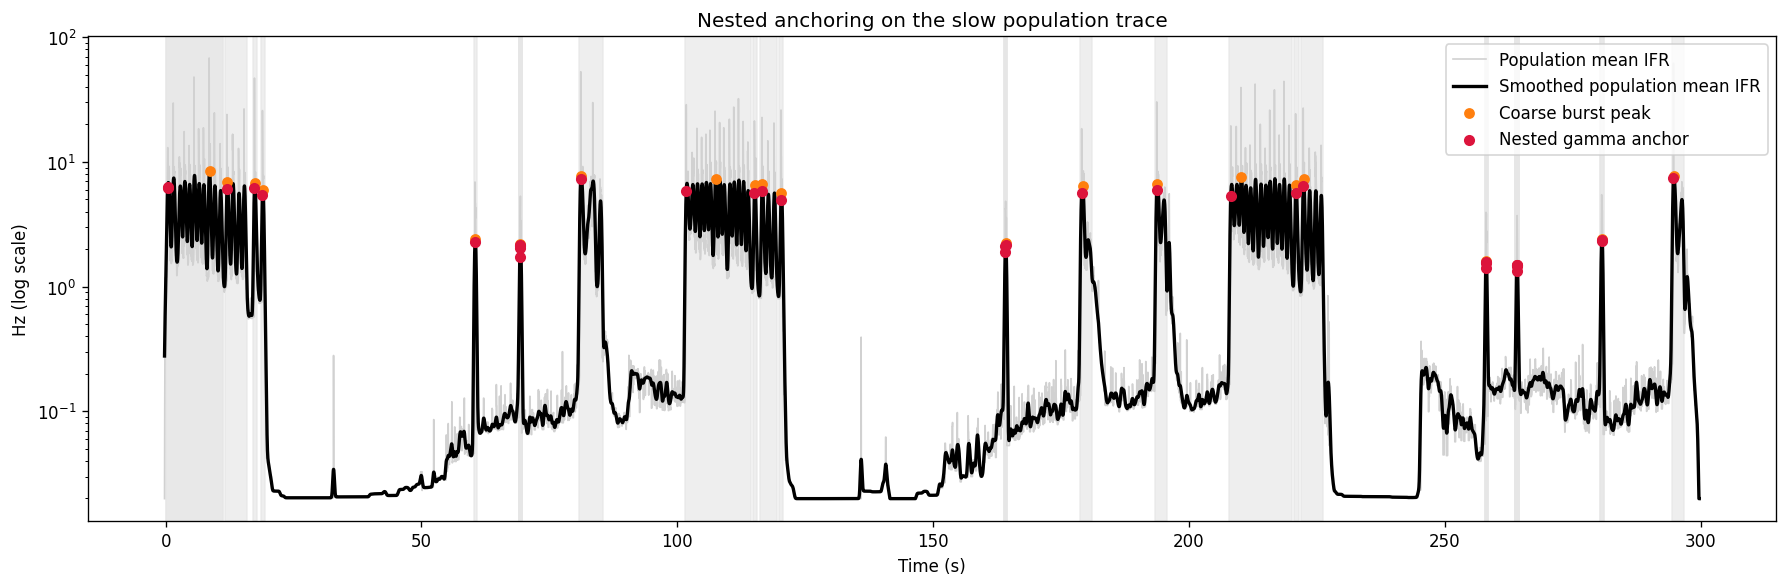

,event_idx,start_time_s,end_time_s,coarse_peak_time_s,onset_time_s,anchor_time_s,gamma_anchor_delay_ms,subpeak_count,n_leading_gamma_peaks
0,0,0.016,11.276,8.576,0.386,0.393,7.0,8,2
1,0,0.016,11.276,8.576,0.386,0.414,28.0,8,2
2,1,11.616,15.856,12.076,11.962,11.980,18.0,4,1
3,2,17.076,17.936,17.436,17.343,17.357,14.0,1,1
4,3,18.616,19.396,18.996,18.906,18.924,18.0,1,1
5,4,60.216,60.836,60.516,60.400,60.457,57.0,1,2
6,5,69.016,69.676,69.336,69.199,69.223,24.0,1,5
7,5,69.016,69.676,69.336,69.199,69.274,75.0,1,5
8,5,69.016,69.676,69.336,69.199,69.294,95.0,1,5
9,5,69.016,69.676,69.336,69.199,69.311,112.0,1,5


In [446]:
slow_positive = mean_ifr_smooth[mean_ifr_smooth > 0]
slow_floor = max(1e-2, float(np.quantile(slow_positive, 0.02)))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time_grid, np.clip(mean_ifr, slow_floor, None), color="0.82", lw=1.0, label="Population mean IFR")
ax.plot(time_grid, np.clip(mean_ifr_smooth, slow_floor, None), color="black", lw=2.0, label="Smoothed population mean IFR")

for row in nested_anchors.itertuples(index=False):
    ax.axvspan(row.start_time_s, row.end_time_s, color="0.90", alpha=0.65)

ax.scatter(
    coarse_epochs["coarse_peak_time_s"],
    np.clip(np.interp(coarse_epochs["coarse_peak_time_s"], time_grid, mean_ifr_smooth), slow_floor, None),
    color="tab:orange",
    s=30,
    zorder=3,
    label="Coarse burst peak",
)
ax.scatter(
    nested_anchors["anchor_time_s"],
    np.clip(np.interp(nested_anchors["anchor_time_s"], time_grid, mean_ifr_smooth), slow_floor, None),
    color="crimson",
    s=32,
    zorder=4,
    label="Nested gamma anchor",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Hz (log scale)")
ax.set_yscale("log")
ax.set_title("Nested anchoring on the slow population trace")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

nested_anchors[[
    "coarse_event_idx",
    "start_time_s",
    "end_time_s",
    "coarse_peak_time_s",
    "onset_time_s",
    "anchor_time_s",
    "gamma_anchor_delay_ms",
    "subpeak_count",
    "n_local_peaks",
    "n_passing_prominence",
    "n_kept_gamma_peaks",
    "prominence_floor_hz",
    "keep_height_floor_hz",
]].round(3)


## Burst vs. Non-Burst IFR Histogram
Use the coarse burst epochs to split the shared IFR matrix into burst and non-burst time samples. The histograms below pool IFR values across all selected electrodes, so each bin reflects the distribution of electrode-time IFR samples inside versus outside the burst windows.


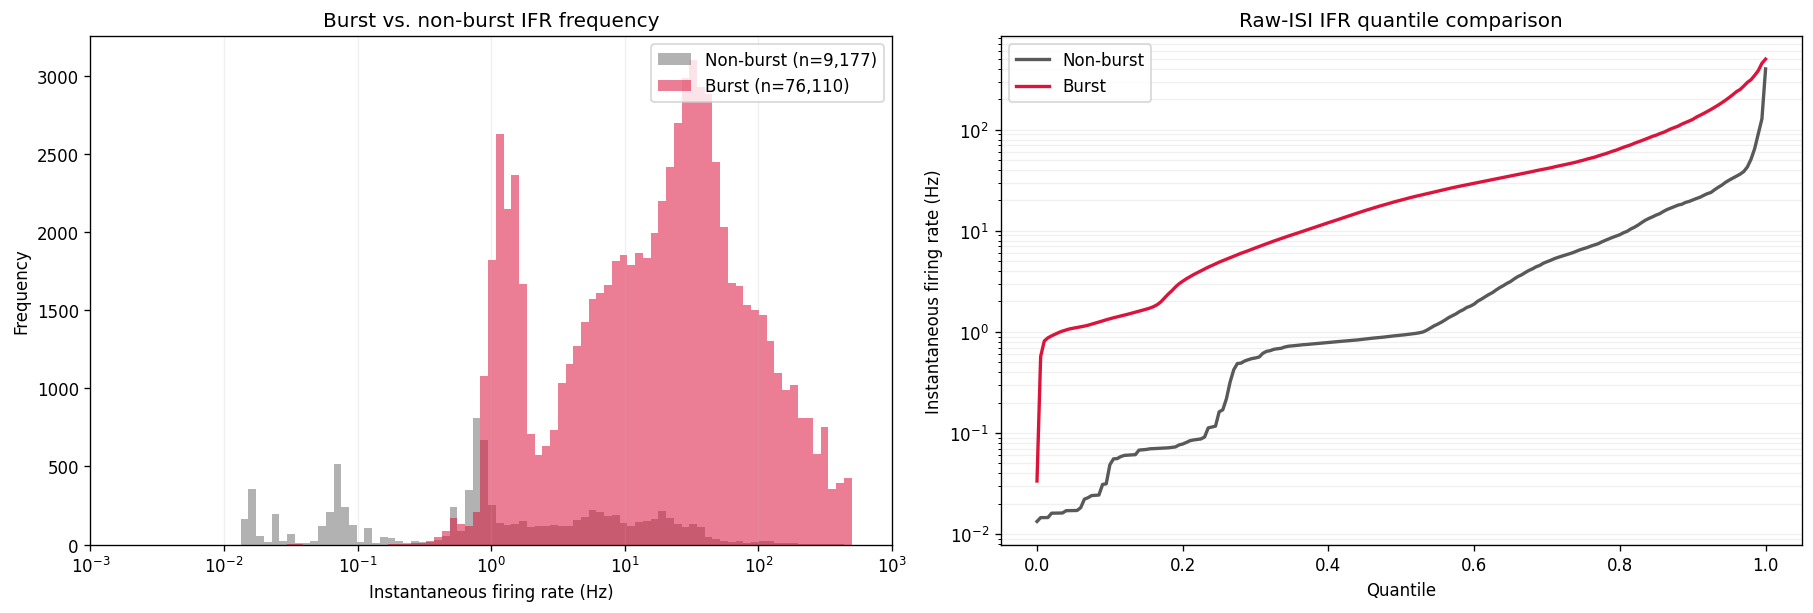

,period,n_samples,median_ifr_hz,mean_ifr_hz,p90_ifr_hz,p99_ifr_hz
0,burst,76110,20.161,47.201,126.582,384.615
1,non_burst,9177,0.929,7.310,20.218,91.109


In [447]:
burst_intervals = coarse_epochs[["start_time_s", "end_time_s"]].to_numpy(dtype=float)

def interval_midpoints_in_bursts(midpoints_s, intervals_s):
    if intervals_s.size == 0 or midpoints_s.size == 0:
        return np.zeros(midpoints_s.shape, dtype=bool)
    membership = np.zeros(midpoints_s.shape, dtype=bool)
    for start_s, end_s in intervals_s:
        membership |= (midpoints_s >= float(start_s)) & (midpoints_s <= float(end_s))
    return membership

raw_burst_ifr = []
raw_nonburst_ifr = []
spike_times_all = np.asarray(rec.spikes["time"], dtype=float)
spike_electrodes_all = np.asarray(rec.spikes["electrode"], dtype=int)
selected_electrodes = np.asarray(refs, dtype=int)

for electrode in selected_electrodes:
    electrode_times = np.sort(
        spike_times_all[
            (spike_electrodes_all == int(electrode))
            & (spike_times_all >= rec.start_time)
            & (spike_times_all <= rec.end_time)
        ]
    )
    if electrode_times.size < 2:
        continue

    interval_starts = electrode_times[:-1]
    interval_stops = electrode_times[1:]
    isi_s = interval_stops - interval_starts
    valid_mask = isi_s > 0
    if not np.any(valid_mask):
        continue

    isi_s = isi_s[valid_mask]
    interval_midpoints = 0.5 * (interval_starts[valid_mask] + interval_stops[valid_mask])
    ifr_values_hz = 1.0 / isi_s

    in_burst = interval_midpoints_in_bursts(interval_midpoints, burst_intervals)
    raw_burst_ifr.append(ifr_values_hz[in_burst])
    raw_nonburst_ifr.append(ifr_values_hz[~in_burst])

if not raw_burst_ifr or not raw_nonburst_ifr:
    raise ValueError("Could not extract raw IFR values for both burst and non-burst periods.")

burst_ifr_positive = np.concatenate([vals for vals in raw_burst_ifr if vals.size > 0]).astype(float)
nonburst_ifr_positive = np.concatenate([vals for vals in raw_nonburst_ifr if vals.size > 0]).astype(float)

if burst_ifr_positive.size == 0:
    raise ValueError("No raw positive IFR values were found inside the burst epochs.")
if nonburst_ifr_positive.size == 0:
    raise ValueError("No raw positive IFR values were found outside the burst epochs.")

log_burst_ifr = np.log10(np.clip(burst_ifr_positive, 1e-12, None))
log_nonburst_ifr = np.log10(np.clip(nonburst_ifr_positive, 1e-12, None))
log_floor = min(float(log_burst_ifr.min()), float(log_nonburst_ifr.min()))
log_ceiling = max(float(log_burst_ifr.max()), float(log_nonburst_ifr.max()))
if np.isclose(log_floor, log_ceiling):
    log_ceiling = log_floor + 1.0
log_hist_bins = np.linspace(log_floor, log_ceiling, 80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axes[0].hist(
    log_nonburst_ifr,
    bins=log_hist_bins,
    alpha=0.55,
    color="0.45",
    label=f"Non-burst (n={nonburst_ifr_positive.size:,})",
)
axes[0].hist(
    log_burst_ifr,
    bins=log_hist_bins,
    alpha=0.55,
    color="crimson",
    label=f"Burst (n={burst_ifr_positive.size:,})",
)
log_ticks = axes[0].get_xticks()
axes[0].set_xticks(log_ticks)
axes[0].set_xticklabels([f"$10^{{{int(x)}}}$" if float(x).is_integer() else f"$10^{{{x:.1f}}}$" for x in log_ticks])
axes[0].set_xlabel("Instantaneous firing rate (Hz)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Burst vs. non-burst IFR frequency")
axes[0].legend(loc="upper right")
axes[0].grid(True, axis="x", alpha=0.18)

quantile_grid = np.linspace(0.0, 1.0, 201)
burst_quantiles = np.quantile(burst_ifr_positive, quantile_grid)
nonburst_quantiles = np.quantile(nonburst_ifr_positive, quantile_grid)
axes[1].plot(quantile_grid, nonburst_quantiles, color="0.35", lw=2.0, label="Non-burst")
axes[1].plot(quantile_grid, burst_quantiles, color="crimson", lw=2.0, label="Burst")
axes[1].set_yscale("log")
axes[1].set_xlabel("Quantile")
axes[1].set_ylabel("Instantaneous firing rate (Hz)")
axes[1].set_title("Raw-ISI IFR quantile comparison")
axes[1].legend(loc="upper left")
axes[1].grid(True, which="both", axis="y", alpha=0.18)

plt.show()

summary_rows = [
    {
        "period": "burst",
        "n_samples": int(burst_ifr_positive.size),
        "median_ifr_hz": float(np.median(burst_ifr_positive)),
        "mean_ifr_hz": float(np.mean(burst_ifr_positive)),
        "p90_ifr_hz": float(np.quantile(burst_ifr_positive, 0.90)),
        "p99_ifr_hz": float(np.quantile(burst_ifr_positive, 0.99)),
    },
    {
        "period": "non_burst",
        "n_samples": int(nonburst_ifr_positive.size),
        "median_ifr_hz": float(np.median(nonburst_ifr_positive)),
        "mean_ifr_hz": float(np.mean(nonburst_ifr_positive)),
        "p90_ifr_hz": float(np.quantile(nonburst_ifr_positive, 0.90)),
        "p99_ifr_hz": float(np.quantile(nonburst_ifr_positive, 0.99)),
    },
]

pd.DataFrame(summary_rows).round(3)


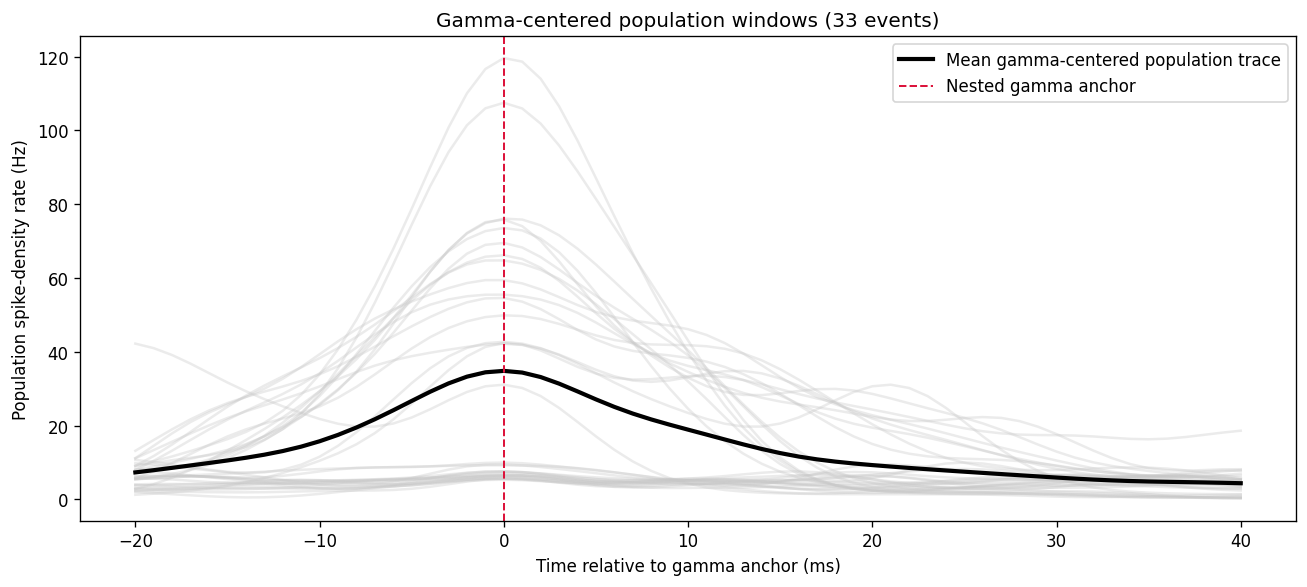

Valid gamma-centered windows: 33
Aligned tensor shape: (33, 300, 61)


In [448]:
pre_bins = int(round(ALIGN_PRE_MS / HIGHRES_BIN_MS))
post_bins = int(round(ALIGN_POST_MS / HIGHRES_BIN_MS))
relative_time_ms = (np.arange(-pre_bins, post_bins + 1) * HIGHRES_BIN_MS).astype(float)

time_centers_highres = highres_data["time_centers_s"]
population_rate_highres = highres_data["population_rate_hz"]
per_electrode_rate_highres = highres_data["per_electrode_rate_hz"]
selected_electrodes = highres_data["electrodes"]

population_windows = []
aligned_tensor = []
valid_nested_anchor_rows = []
for row in nested_anchors.itertuples(index=False):
    anchor_idx = int(np.argmin(np.abs(time_centers_highres - row.anchor_time_s)))
    window_start = anchor_idx - pre_bins
    window_stop = anchor_idx + post_bins + 1
    if window_start < 0 or window_stop > len(time_centers_highres):
        continue

    population_windows.append(population_rate_highres[window_start:window_stop])
    aligned_tensor.append(per_electrode_rate_highres[:, window_start:window_stop])
    valid_nested_anchor_rows.append(row._asdict())

population_windows = np.asarray(population_windows, dtype=float)
aligned_tensor = np.asarray(aligned_tensor, dtype=float)
valid_nested_anchors = pd.DataFrame(valid_nested_anchor_rows)

fig, ax = plt.subplots(figsize=(11, 5))
for row in population_windows:
    ax.plot(relative_time_ms, row, color="0.78", alpha=0.35)
ax.plot(relative_time_ms, population_windows.mean(axis=0), color="black", lw=2.5, label="Mean gamma-centered population trace")
ax.axvline(0.0, color="crimson", ls="--", lw=1.2, label="Nested gamma anchor")
ax.set_xlabel("Time relative to gamma anchor (ms)")
ax.set_ylabel("Population spike-density rate (Hz)")
ax.set_title(f"Gamma-centered population windows ({len(valid_nested_anchors)} events)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Valid gamma-centered windows: {len(valid_nested_anchors)}")
print(f"Aligned tensor shape: {aligned_tensor.shape}")


## Example Gamma-Centered IFR Time Series
Before averaging across events, inspect a small set of individual gamma-centered windows using the exact same `ALIGN_PRE_MS` / `ALIGN_POST_MS` alignment used in the overlay below. By default, the notebook shows the strongest nested gamma anchors by `anchor_height_hz`.


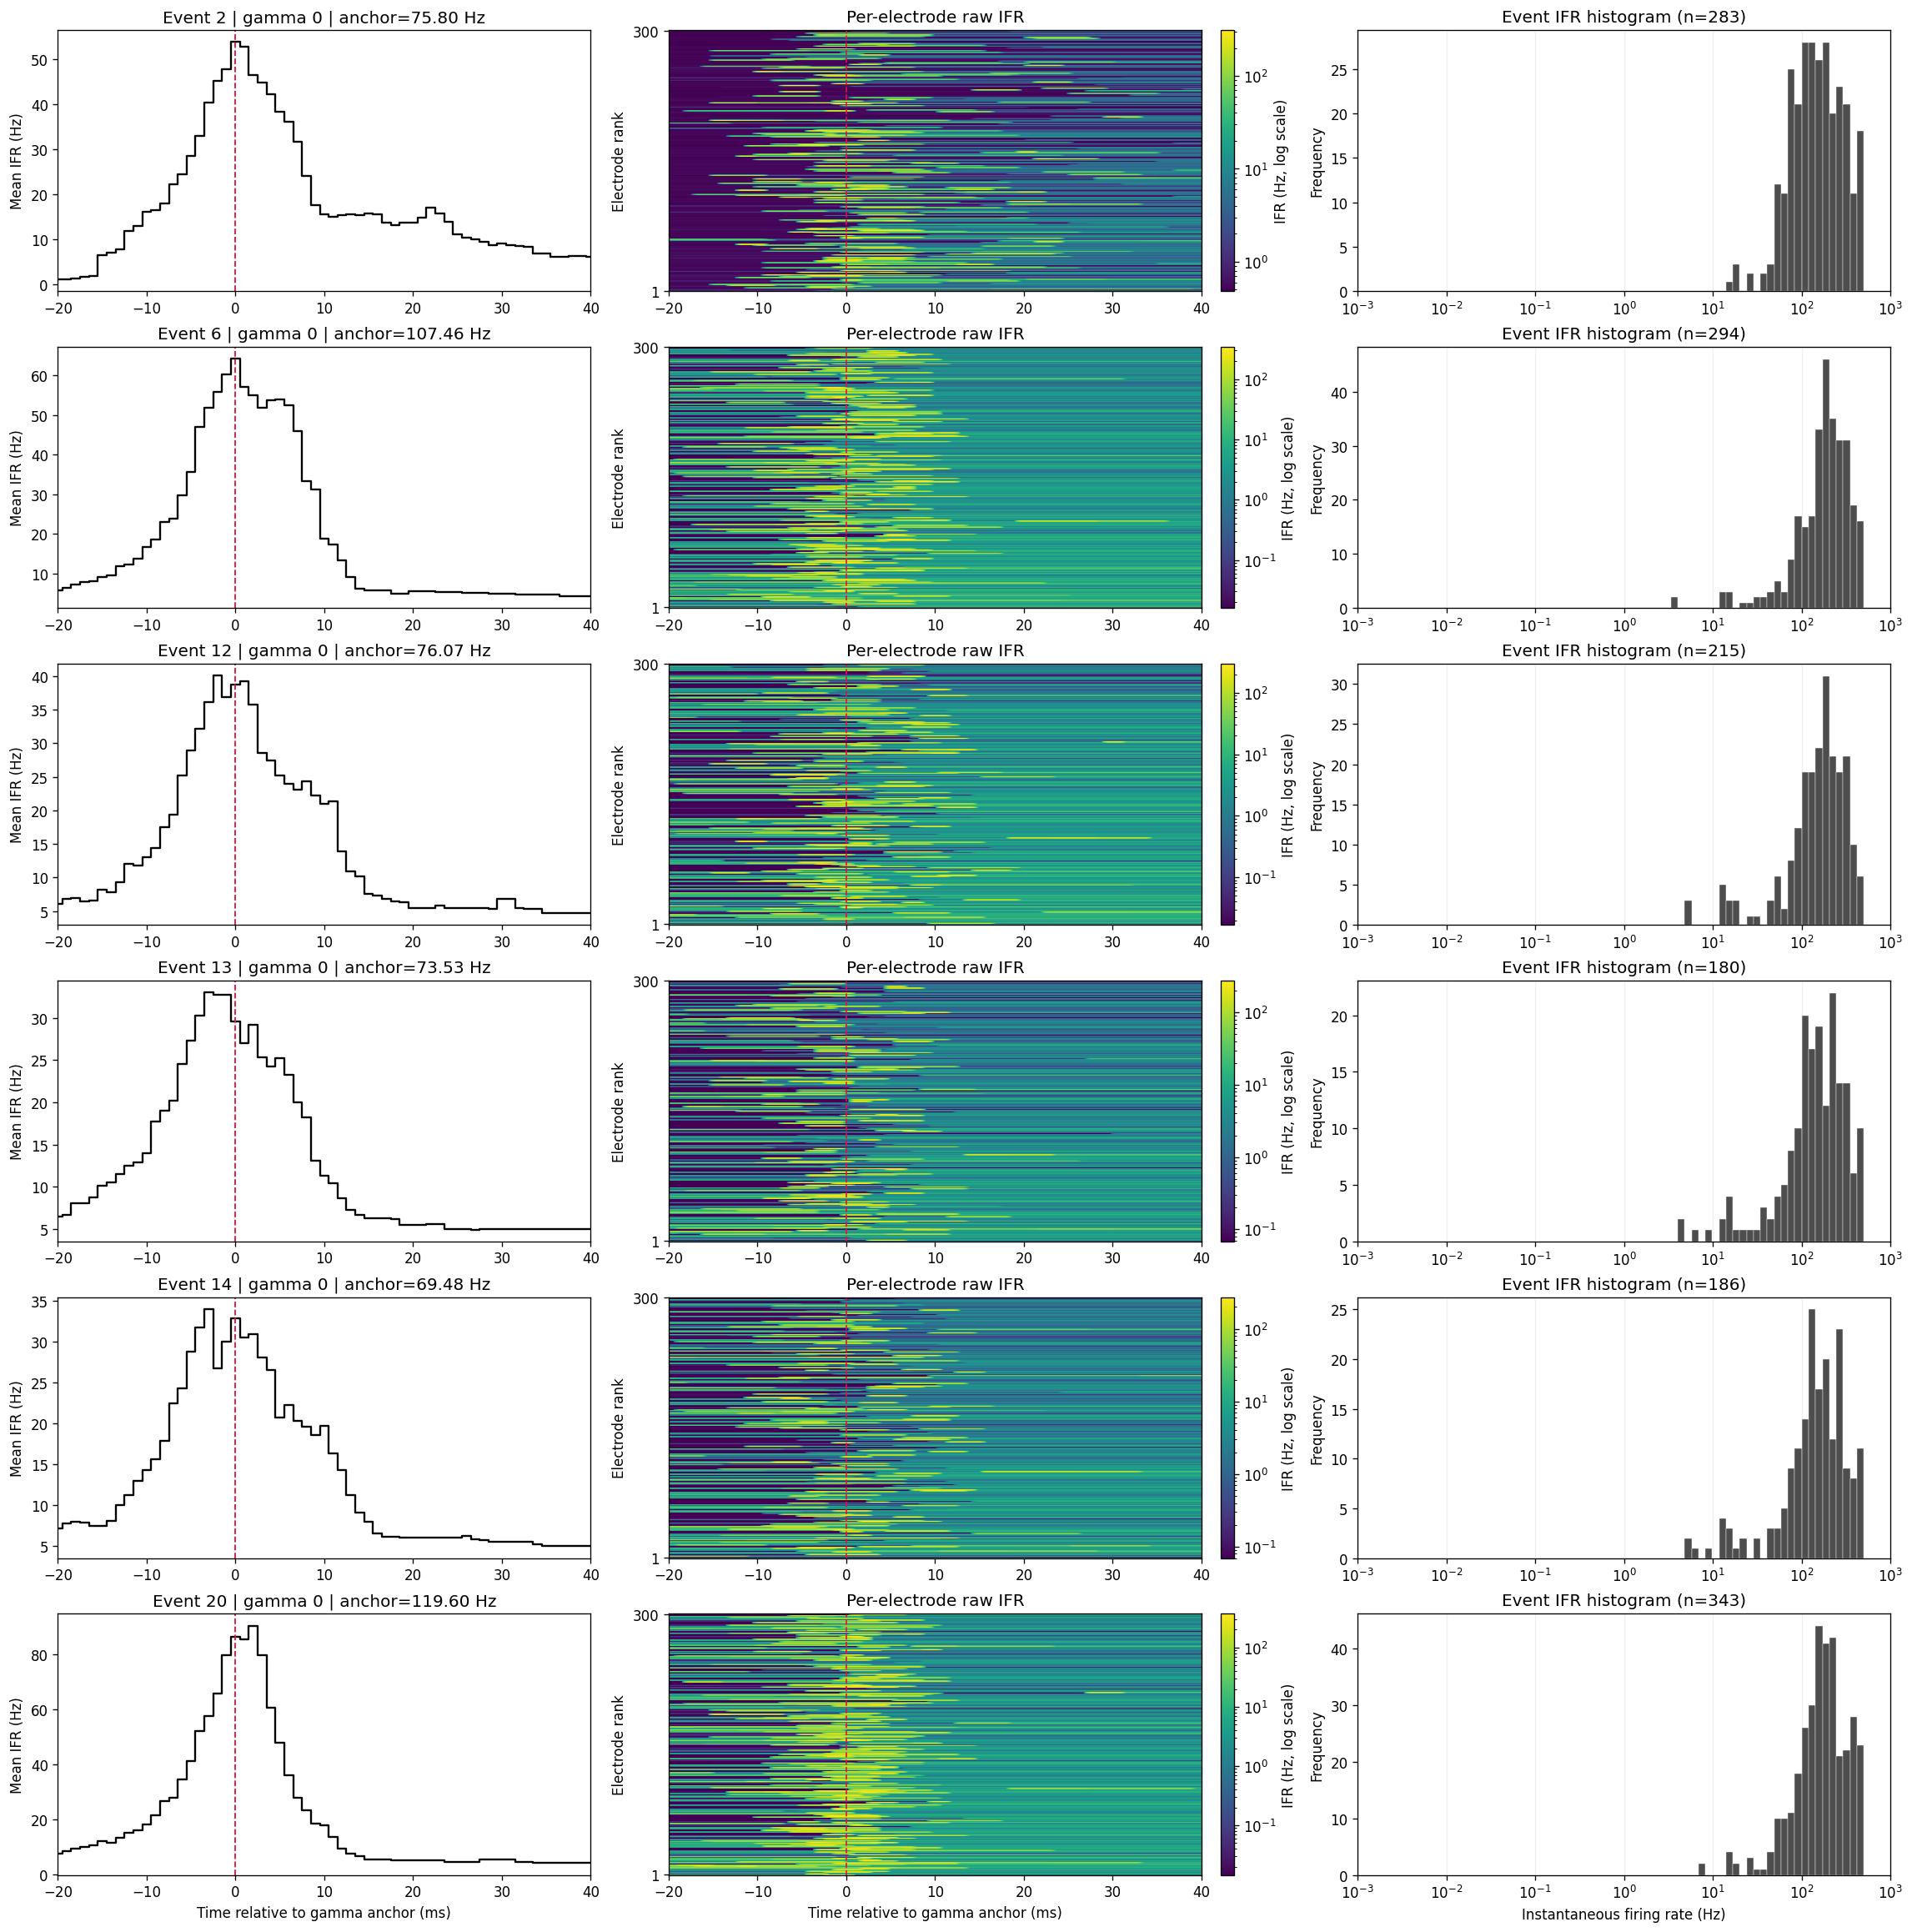

,coarse_event_idx,gamma_peak_rank,anchor_time_s,anchor_height_hz,gamma_anchor_delay_ms,subpeak_count
0,2,0,17.357,75.801,14.0,1
1,6,0,81.133,107.463,11.0,3
2,12,0,179.044,76.070,13.0,1
3,13,0,193.720,73.527,13.0,2
4,14,0,208.189,69.481,58.0,7
5,20,0,294.719,119.598,11.0,2


In [449]:
if len(valid_nested_anchors) == 0:
    raise ValueError("No valid gamma-centered windows were available for event-level inspection.")

raw_ifr_data, _, _ = calculate_ifr(
    rec.spikes,
    refs,
    rec.start_time,
    rec.end_time,
)

selected_electrodes = np.asarray(refs, dtype=int)
spike_times_all = np.asarray(rec.spikes["time"], dtype=float)
spike_electrodes_all = np.asarray(rec.spikes["electrode"], dtype=int)

raw_ifr_highres = []
interval_midpoints_by_electrode = {}
interval_ifr_by_electrode = {}
for electrode in selected_electrodes:
    if int(electrode) in raw_ifr_data:
        ifr_times, ifr_values = raw_ifr_data[int(electrode)]
        value_idx = np.searchsorted(ifr_times, time_centers_highres, side="right") - 1
        value_idx = np.clip(value_idx, 0, len(ifr_values) - 1)
        raw_ifr_highres.append(ifr_values[value_idx])
    else:
        raw_ifr_highres.append(np.zeros_like(time_centers_highres, dtype=float))

    electrode_spike_times = np.sort(
        spike_times_all[
            (spike_electrodes_all == int(electrode))
            & (spike_times_all >= rec.start_time)
            & (spike_times_all <= rec.end_time)
        ]
    )
    if electrode_spike_times.size < 2:
        interval_midpoints_by_electrode[int(electrode)] = np.array([], dtype=float)
        interval_ifr_by_electrode[int(electrode)] = np.array([], dtype=float)
        continue

    isi_s = np.diff(electrode_spike_times)
    valid_isi = isi_s > 0
    interval_midpoints_by_electrode[int(electrode)] = 0.5 * (
        electrode_spike_times[:-1][valid_isi] + electrode_spike_times[1:][valid_isi]
    )
    interval_ifr_by_electrode[int(electrode)] = 1.0 / isi_s[valid_isi]

raw_ifr_highres = np.asarray(raw_ifr_highres, dtype=float)
all_interval_ifr = np.concatenate(
    [vals for vals in interval_ifr_by_electrode.values() if vals.size > 0]
).astype(float)
if all_interval_ifr.size == 0:
    raise ValueError("No positive ISI-derived IFR values were found for the selected electrodes.")
global_log_bins = np.linspace(
    float(np.log10(np.clip(all_interval_ifr, 1e-12, None)).min()),
    float(np.log10(np.clip(all_interval_ifr, 1e-12, None)).max()),
    60,
)

example_event_count = min(int(EXAMPLE_GAMMA_EVENT_COUNT), len(valid_nested_anchors))
example_order = np.argsort(valid_nested_anchors["anchor_height_hz"].to_numpy(dtype=float))[::-1]
example_indices = example_order[:example_event_count]
example_events = valid_nested_anchors.iloc[example_indices].copy()
example_events["window_idx"] = example_indices
example_events = example_events.sort_values(["coarse_event_idx", "gamma_peak_rank"]).reset_index(drop=True)

fig, axes = plt.subplots(
    example_event_count,
    3,
    figsize=(19, max(3.2 * example_event_count, 4.0)),
    constrained_layout=True,
    squeeze=False,
)

for row_idx, row in enumerate(example_events.itertuples(index=False)):
    anchor_idx = int(np.argmin(np.abs(time_centers_highres - row.anchor_time_s)))
    window_start = anchor_idx - pre_bins
    window_stop = anchor_idx + post_bins + 1
    if window_start < 0 or window_stop > len(time_centers_highres):
        continue

    event_start_s = float(row.anchor_time_s) - float(ALIGN_PRE_MS) / 1000.0
    event_end_s = float(row.anchor_time_s) + float(ALIGN_POST_MS) / 1000.0

    electrode_window = raw_ifr_highres[:, window_start:window_stop]
    pop_trace = electrode_window.mean(axis=0)
    event_interval_ifr = []
    for electrode in selected_electrodes:
        mids = interval_midpoints_by_electrode[int(electrode)]
        vals = interval_ifr_by_electrode[int(electrode)]
        in_window = (mids >= event_start_s) & (mids <= event_end_s)
        if np.any(in_window):
            event_interval_ifr.append(vals[in_window])
    event_interval_ifr = np.concatenate(event_interval_ifr).astype(float) if event_interval_ifr else np.array([], dtype=float)

    ax_line = axes[row_idx, 0]
    ax_heat = axes[row_idx, 1]
    ax_hist = axes[row_idx, 2]

    ax_line.step(relative_time_ms, pop_trace, where="mid", color="black", lw=1.4)
    ax_line.axvline(0.0, color="crimson", ls="--", lw=1.1)
    ax_line.set_ylabel("Mean IFR (Hz)")
    ax_line.set_title(
        f"Event {int(row.coarse_event_idx)} | gamma {int(row.gamma_peak_rank)} | anchor={float(row.anchor_height_hz):.2f} Hz"
    )
    ax_line.set_xlim(float(relative_time_ms[0]), float(relative_time_ms[-1]))

    positive_vals = electrode_window[electrode_window > 0]
    if positive_vals.size == 0:
        heat_vmin = 1e-3
        heat_vmax = 1.0
    else:
        heat_vmin = max(1e-3, float(np.quantile(positive_vals, 0.02)))
        heat_vmax = max(heat_vmin * 10.0, float(np.quantile(positive_vals, 0.995)))
    display_window = np.clip(electrode_window, heat_vmin, heat_vmax)

    im = ax_heat.imshow(
        display_window,
        aspect="auto",
        origin="lower",
        extent=[float(relative_time_ms[0]), float(relative_time_ms[-1]), 0.5, electrode_window.shape[0] + 0.5],
        cmap="viridis",
        norm=LogNorm(vmin=heat_vmin, vmax=heat_vmax),
    )
    ax_heat.axvline(0.0, color="crimson", ls="--", lw=1.0)
    ax_heat.set_title("Per-electrode raw IFR")
    ax_heat.set_ylabel("Electrode rank")
    ax_heat.set_yticks([1, electrode_window.shape[0]])
    ax_heat.set_xlim(float(relative_time_ms[0]), float(relative_time_ms[-1]))

    if event_interval_ifr.size > 0:
        event_log_ifr = np.log10(np.clip(event_interval_ifr, 1e-12, None))
        ax_hist.hist(
            event_log_ifr,
            bins=global_log_bins,
            color="0.30",
            edgecolor="white",
            linewidth=0.25,
        )
    ax_hist.set_title(f"Event IFR histogram (n={int(event_interval_ifr.size)})")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(True, axis="x", alpha=0.18)
    hist_ticks = ax_hist.get_xticks()
    ax_hist.set_xticks(hist_ticks)
    ax_hist.set_xticklabels(
        [f"$10^{{{int(x)}}}$" if float(x).is_integer() else f"$10^{{{x:.1f}}}$" for x in hist_ticks],
        rotation=0,
    )

    if row_idx == example_event_count - 1:
        ax_line.set_xlabel("Time relative to gamma anchor (ms)")
        ax_heat.set_xlabel("Time relative to gamma anchor (ms)")
        ax_hist.set_xlabel("Instantaneous firing rate (Hz)")

    cbar = fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.02)
    cbar.set_label("IFR (Hz, log scale)")
    cbar.locator = LogLocator(base=10)
    cbar.formatter = LogFormatterMathtext(base=10)
    cbar.update_ticks()

plt.show()

example_events[[
    "coarse_event_idx",
    "gamma_peak_rank",
    "anchor_time_s",
    "anchor_height_hz",
    "gamma_anchor_delay_ms",
    "subpeak_count",
]].round(3)


## Gamma-Centered Propagation Summary

Average the high-resolution, per-electrode spike-density traces across all valid nested anchors and sort electrodes by how strongly they fire around the gamma peak. This pushes the most active, most rhythmically re-firing electrodes to the top of the view.


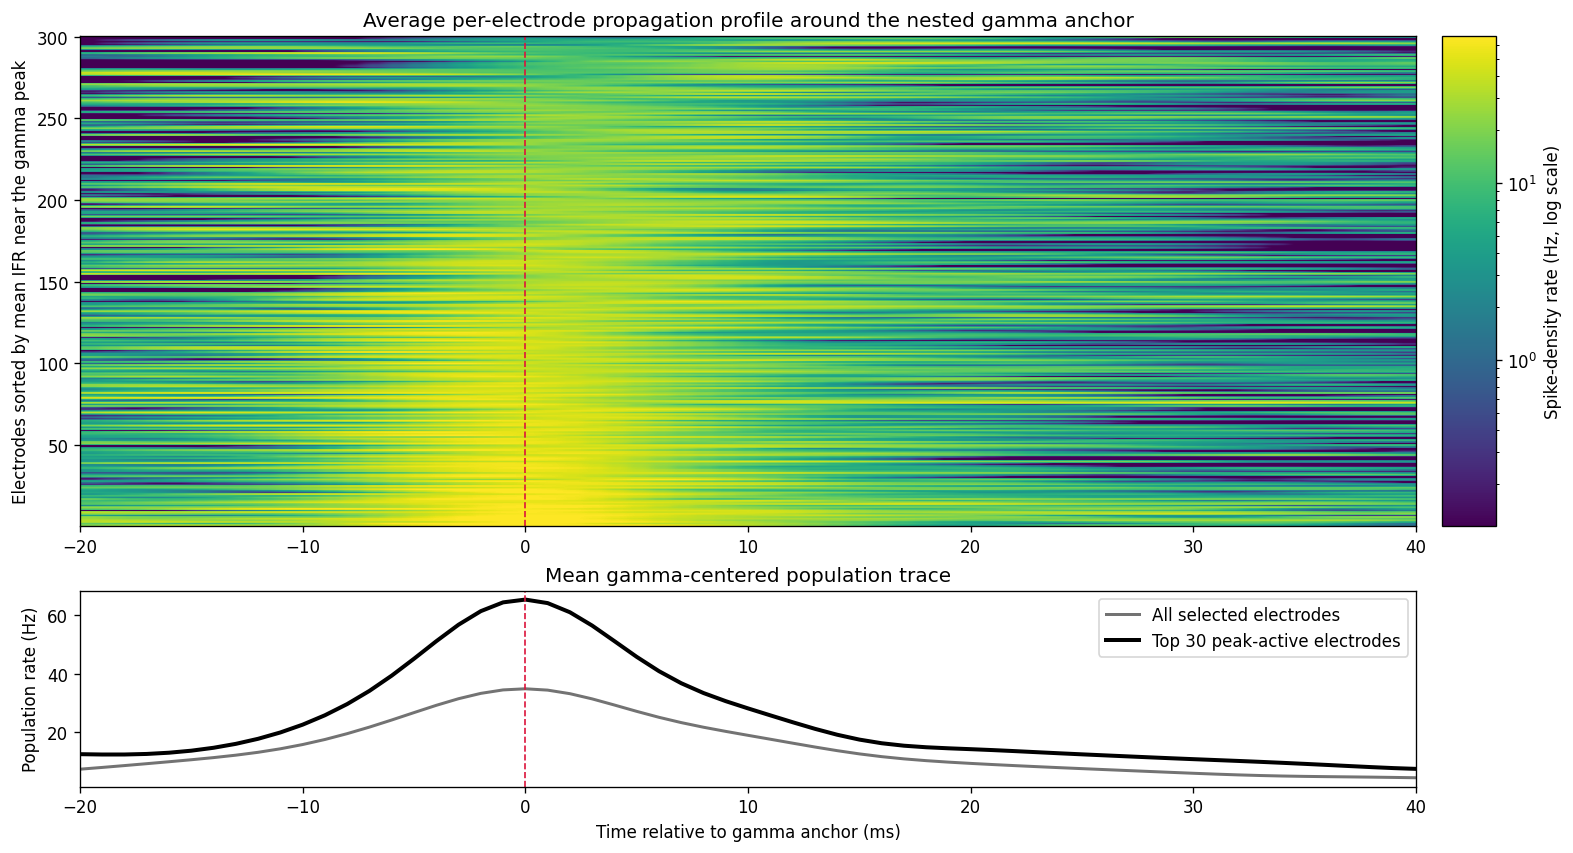

,electrode,window_mean_hz,peak_window_mean_hz,rebound_window_mean_hz,anchor_rate_hz,max_rate_hz
0,6841,28.884702,63.687891,7.977602,77.540141,77.723215
1,17829,25.908724,62.083329,5.821382,87.343637,100.882551
2,8635,29.021421,56.599972,6.521173,75.587004,80.367160
3,23107,34.286436,56.494595,18.949743,76.075538,76.185327
4,18267,33.127488,56.097030,22.738118,77.203306,77.203306
5,15653,27.386497,56.023830,18.390098,77.729839,77.827383
6,23703,23.083234,55.524404,20.035893,74.785627,76.283009
7,3781,33.096727,53.693735,23.465967,63.747344,64.421659
8,23287,37.026490,51.909690,31.054178,67.058864,67.295732
9,12273,21.420944,51.842032,16.395562,65.949209,68.254728


In [450]:
mean_aligned_electrode_rate = aligned_tensor.mean(axis=0)
peak_window_mask = (relative_time_ms >= -SORT_PEAK_PRE_MS) & (relative_time_ms <= SORT_PEAK_POST_MS)
rebound_window_mask = (relative_time_ms >= 15.0) & (relative_time_ms <= 25.0)

rate_summary = pd.DataFrame(
    {
        "electrode": selected_electrodes.astype(int),
        "window_mean_hz": mean_aligned_electrode_rate.mean(axis=1),
        "peak_window_mean_hz": mean_aligned_electrode_rate[:, peak_window_mask].mean(axis=1),
        "rebound_window_mean_hz": mean_aligned_electrode_rate[:, rebound_window_mask].mean(axis=1),
        "anchor_rate_hz": mean_aligned_electrode_rate[:, relative_time_ms == 0.0].reshape(-1),
        "max_rate_hz": mean_aligned_electrode_rate.max(axis=1),
    }
).sort_values(
    ["peak_window_mean_hz", "rebound_window_mean_hz", "max_rate_hz", "electrode"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

ordered_electrodes = rate_summary["electrode"].to_numpy(dtype=int)
ordered_idx = np.array([np.flatnonzero(selected_electrodes == int(el))[0] for el in ordered_electrodes], dtype=int)
ordered_aligned_rate = mean_aligned_electrode_rate[ordered_idx]
top_active_count = min(60, max(10, ordered_aligned_rate.shape[0] // 10))
top_active_trace = ordered_aligned_rate[:top_active_count].mean(axis=0)

positive_aligned = ordered_aligned_rate[ordered_aligned_rate > 0]
aligned_vmin = max(1e-2, float(np.quantile(positive_aligned, 0.05)))
aligned_vmax = max(aligned_vmin * 10.0, float(np.quantile(positive_aligned, 0.995)))

fig = plt.figure(figsize=(13, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.2], width_ratios=[40.0, 1.6])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
cax = fig.add_subplot(gs[0, 1])
fig.add_subplot(gs[1, 1]).axis("off")

im = ax0.imshow(
    np.clip(ordered_aligned_rate, aligned_vmin, aligned_vmax),
    aspect="auto",
    origin="lower",
    extent=[relative_time_ms[0], relative_time_ms[-1], 0.5, ordered_aligned_rate.shape[0] + 0.5],
    cmap="viridis",
    norm=LogNorm(vmin=aligned_vmin, vmax=aligned_vmax),
)
ax0.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax0.set_ylabel("Electrodes sorted by mean IFR near the gamma peak")
ax0.set_title("Average per-electrode propagation profile around the nested gamma anchor")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Spike-density rate (Hz, log scale)")
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatterMathtext(base=10)
cbar.update_ticks()

ax1.plot(relative_time_ms, population_windows.mean(axis=0), color="0.45", lw=1.8, label="All selected electrodes")
ax1.plot(relative_time_ms, top_active_trace, color="black", lw=2.4, label=f"Top {top_active_count} peak-active electrodes")
ax1.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax1.set_xlabel("Time relative to gamma anchor (ms)")
ax1.set_ylabel("Population rate (Hz)")
ax1.set_title("Mean gamma-centered population trace")
ax1.legend(loc="upper right")
plt.show()

rate_summary.head(20)


## Peak-Time Ordered Propagation View

Sort electrodes by the timepoint of their own maximal mean IFR relative to the nested gamma anchor. This emphasizes ordering by when each electrode peaks, rather than by how strongly it fires.


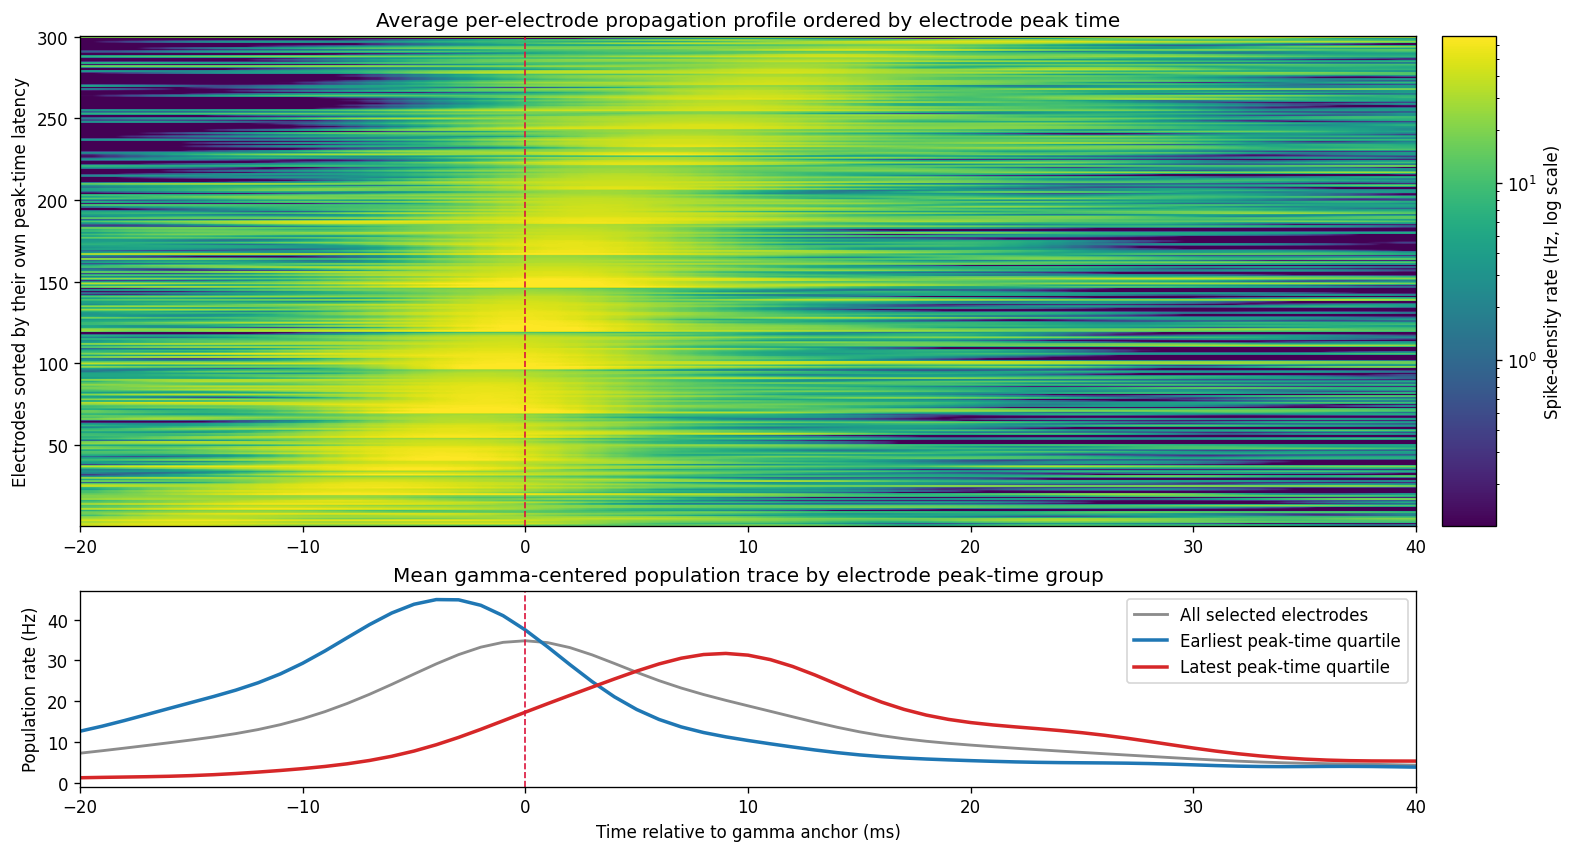

,electrode,peak_time_ms,peak_rate_hz,peak_window_mean_hz,rebound_window_mean_hz
0,4381,-17.0,48.627304,13.993043,9.780801
1,1689,-16.0,49.346042,27.346022,1.982453
2,4201,-16.0,41.902206,23.493737,11.657890
3,2879,-15.0,57.929976,34.490918,20.636048
4,5189,-15.0,37.528178,27.895331,21.076832
5,18271,-15.0,33.439516,24.655504,1.864481
6,3765,-14.0,34.755679,16.376622,3.713650
7,3763,-13.0,52.614252,24.685076,5.511622
8,4181,-13.0,25.163988,13.624279,8.303327
9,6127,-13.0,21.773980,9.025467,0.006050


In [451]:
peak_time_idx = np.argmax(mean_aligned_electrode_rate, axis=1)
peak_time_summary = rate_summary.merge(
    pd.DataFrame(
        {
            "electrode": selected_electrodes.astype(int),
            "peak_time_ms": relative_time_ms[peak_time_idx],
            "peak_rate_hz": mean_aligned_electrode_rate[np.arange(mean_aligned_electrode_rate.shape[0]), peak_time_idx],
        }
    ),
    on="electrode",
    how="left",
).sort_values(
    ["peak_time_ms", "peak_rate_hz", "peak_window_mean_hz", "electrode"],
    ascending=[True, False, False, True],
).reset_index(drop=True)

peak_time_electrodes = peak_time_summary["electrode"].to_numpy(dtype=int)
peak_time_order_idx = np.array([np.flatnonzero(selected_electrodes == int(el))[0] for el in peak_time_electrodes], dtype=int)
peak_time_ordered_rate = mean_aligned_electrode_rate[peak_time_order_idx]

early_cutoff = float(peak_time_summary["peak_time_ms"].quantile(0.25))
late_cutoff = float(peak_time_summary["peak_time_ms"].quantile(0.75))
early_trace = peak_time_ordered_rate[peak_time_summary["peak_time_ms"].to_numpy() <= early_cutoff].mean(axis=0)
late_trace = peak_time_ordered_rate[peak_time_summary["peak_time_ms"].to_numpy() >= late_cutoff].mean(axis=0)

peak_time_positive = peak_time_ordered_rate[peak_time_ordered_rate > 0]
peak_time_vmin = max(1e-2, float(np.quantile(peak_time_positive, 0.05)))
peak_time_vmax = max(peak_time_vmin * 10.0, float(np.quantile(peak_time_positive, 0.995)))

fig = plt.figure(figsize=(13, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.2], width_ratios=[40.0, 1.6])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
cax = fig.add_subplot(gs[0, 1])
fig.add_subplot(gs[1, 1]).axis("off")

im = ax0.imshow(
    np.clip(peak_time_ordered_rate, peak_time_vmin, peak_time_vmax),
    aspect="auto",
    origin="lower",
    extent=[relative_time_ms[0], relative_time_ms[-1], 0.5, peak_time_ordered_rate.shape[0] + 0.5],
    cmap="viridis",
    norm=LogNorm(vmin=peak_time_vmin, vmax=peak_time_vmax),
)
ax0.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax0.set_ylabel("Electrodes sorted by their own peak-time latency")
ax0.set_title("Average per-electrode propagation profile ordered by electrode peak time")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Spike-density rate (Hz, log scale)")
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatterMathtext(base=10)
cbar.update_ticks()

ax1.plot(relative_time_ms, population_windows.mean(axis=0), color="0.55", lw=1.7, label="All selected electrodes")
ax1.plot(relative_time_ms, early_trace, color="#1f77b4", lw=2.1, label="Earliest peak-time quartile")
ax1.plot(relative_time_ms, late_trace, color="#d62728", lw=2.1, label="Latest peak-time quartile")
ax1.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax1.set_xlabel("Time relative to gamma anchor (ms)")
ax1.set_ylabel("Population rate (Hz)")
ax1.set_title("Mean gamma-centered population trace by electrode peak-time group")
ax1.legend(loc="upper right")
plt.show()

peak_time_summary[["electrode", "peak_time_ms", "peak_rate_hz", "peak_window_mean_hz", "rebound_window_mean_hz"]].head(20)


## Ordering Correlation

Compare each electrode's rank under the activity-based ordering and the peak-time ordering. If the two orderings track each other, points should cluster near the diagonal.


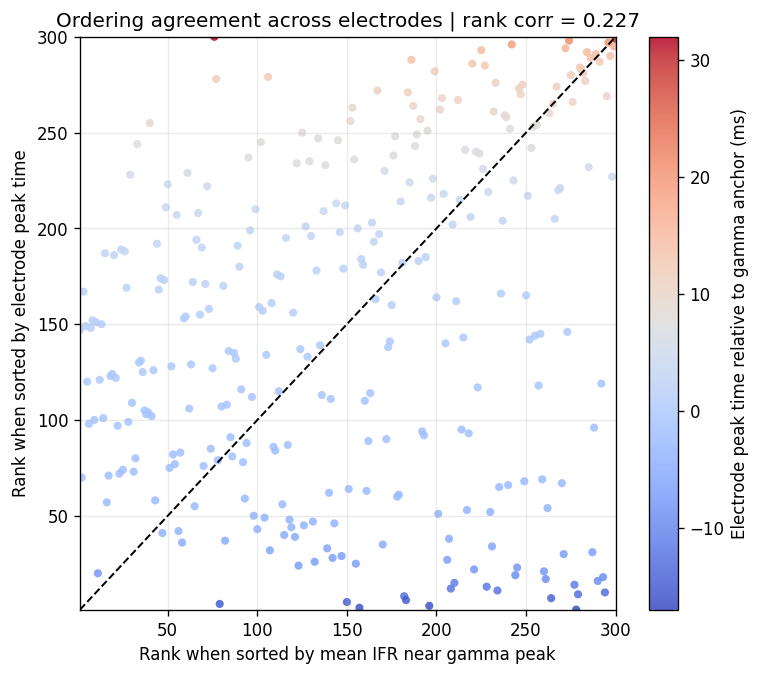

,electrode,peak_activity_rank,peak_time_ms,peak_rate_hz,peak_time_rank
0,6841,1,1.0,77.723215,147
1,17829,2,-2.0,100.882551,70
2,8635,3,2.0,80.367160,167
3,23107,4,1.0,76.185327,149
4,18267,5,0.0,77.203306,120
5,15653,6,-1.0,77.827383,98
6,23703,7,1.0,76.283009,148
7,3781,8,1.0,64.421659,152
8,23287,9,-1.0,67.295732,100
9,12273,10,1.0,68.254728,151


In [452]:
activity_rank = rate_summary[["electrode"]].copy()
activity_rank["peak_activity_rank"] = np.arange(1, len(activity_rank) + 1, dtype=int)

peak_time_rank = peak_time_summary[["electrode", "peak_time_ms", "peak_rate_hz"]].copy()
peak_time_rank["peak_time_rank"] = np.arange(1, len(peak_time_rank) + 1, dtype=int)

ordering_compare = activity_rank.merge(peak_time_rank, on="electrode", how="inner")
rank_corr = float(np.corrcoef(ordering_compare["peak_activity_rank"], ordering_compare["peak_time_rank"])[0, 1])

fig, ax = plt.subplots(figsize=(7.2, 6.2))
scatter = ax.scatter(
    ordering_compare["peak_activity_rank"],
    ordering_compare["peak_time_rank"],
    c=ordering_compare["peak_time_ms"],
    s=24,
    cmap="coolwarm",
    alpha=0.85,
    edgecolors="none",
)
rank_min = 1
rank_max = len(ordering_compare)
ax.plot([rank_min, rank_max], [rank_min, rank_max], color="black", ls="--", lw=1.2)
ax.set_xlim(rank_min, rank_max)
ax.set_ylim(rank_min, rank_max)
ax.set_xlabel("Rank when sorted by mean IFR near gamma peak")
ax.set_ylabel("Rank when sorted by electrode peak time")
ax.set_title(f"Ordering agreement across electrodes | rank corr = {rank_corr:.3f}")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Electrode peak time relative to gamma anchor (ms)")
ax.grid(True, alpha=0.25)
plt.show()

ordering_compare.sort_values("peak_activity_rank").head(20)


## X-Ordered Propagation View

Sort electrodes by their physical `x` position on the array to test the left-to-right propagation hypothesis directly.


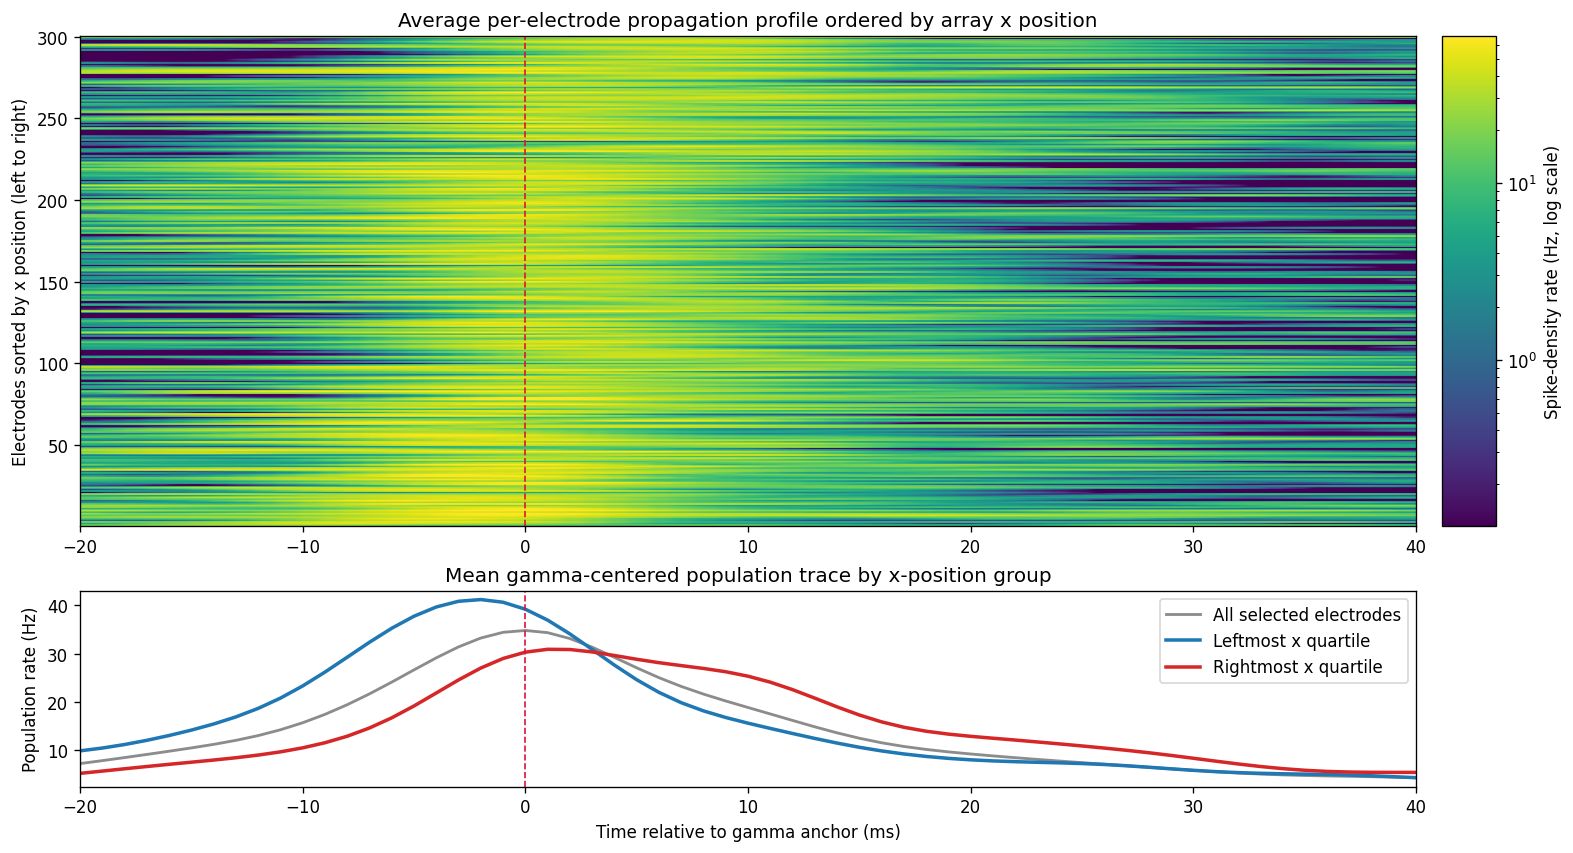

,electrode,x,y,peak_window_mean_hz,rebound_window_mean_hz
0,4181.0,17.5,332.5,13.624279,8.303327
1,20903.0,52.5,1662.5,18.416031,1.179820
2,20465.0,87.5,1627.5,31.190020,8.133706
3,21345.0,87.5,1697.5,21.023288,0.002103
4,22665.0,87.5,1802.5,29.118634,8.071792
5,5507.0,122.5,437.5,32.823615,15.004305
6,17387.0,122.5,1382.5,48.999907,41.602819
7,18267.0,122.5,1452.5,56.097030,22.738118
8,18707.0,122.5,1487.5,29.690250,4.627236
9,23107.0,122.5,1837.5,56.494595,18.949743


In [453]:
layout_df = pd.DataFrame(rec.layout)
layout_df = layout_df[layout_df["electrode"].isin(selected_electrodes)].drop_duplicates("electrode").copy()
layout_df = layout_df.merge(rate_summary, on="electrode", how="left")

x_sorted_layout = layout_df.sort_values(["x", "y", "peak_window_mean_hz", "electrode"], ascending=[True, True, False, True]).reset_index(drop=True)
x_sorted_electrodes = x_sorted_layout["electrode"].to_numpy(dtype=int)
x_sorted_idx = np.array([np.flatnonzero(selected_electrodes == int(el))[0] for el in x_sorted_electrodes], dtype=int)
x_sorted_rate = mean_aligned_electrode_rate[x_sorted_idx]

left_mask = x_sorted_layout["x"] <= x_sorted_layout["x"].quantile(0.25)
right_mask = x_sorted_layout["x"] >= x_sorted_layout["x"].quantile(0.75)
left_trace = x_sorted_rate[left_mask.to_numpy()].mean(axis=0)
right_trace = x_sorted_rate[right_mask.to_numpy()].mean(axis=0)

x_positive = x_sorted_rate[x_sorted_rate > 0]
x_vmin = max(1e-2, float(np.quantile(x_positive, 0.05)))
x_vmax = max(x_vmin * 10.0, float(np.quantile(x_positive, 0.995)))

fig = plt.figure(figsize=(13, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.2], width_ratios=[40.0, 1.6])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
cax = fig.add_subplot(gs[0, 1])
fig.add_subplot(gs[1, 1]).axis("off")

im = ax0.imshow(
    np.clip(x_sorted_rate, x_vmin, x_vmax),
    aspect="auto",
    origin="lower",
    extent=[relative_time_ms[0], relative_time_ms[-1], 0.5, x_sorted_rate.shape[0] + 0.5],
    cmap="viridis",
    norm=LogNorm(vmin=x_vmin, vmax=x_vmax),
)
ax0.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax0.set_ylabel("Electrodes sorted by x position (left to right)")
ax0.set_title("Average per-electrode propagation profile ordered by array x position")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Spike-density rate (Hz, log scale)")
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatterMathtext(base=10)
cbar.update_ticks()

ax1.plot(relative_time_ms, population_windows.mean(axis=0), color="0.55", lw=1.7, label="All selected electrodes")
ax1.plot(relative_time_ms, left_trace, color="#1f77b4", lw=2.1, label="Leftmost x quartile")
ax1.plot(relative_time_ms, right_trace, color="#d62728", lw=2.1, label="Rightmost x quartile")
ax1.axvline(0.0, color="crimson", ls="--", lw=1.0)
ax1.set_xlabel("Time relative to gamma anchor (ms)")
ax1.set_ylabel("Population rate (Hz)")
ax1.set_title("Mean gamma-centered population trace by x-position group")
ax1.legend(loc="upper right")
plt.show()

x_sorted_layout[["electrode", "x", "y", "peak_window_mean_hz", "rebound_window_mean_hz"]].head(20)


## Hex-Tiled Array GIF

Use a coarser hexagonal tiling of the array so the global spread pattern is easier to see. Each frame shows the average high-resolution electrode IFR at that time relative to the nested gamma anchor.


Saved GIF to /Users/danielrebbin/Documents/GitHub/ephax/Notebooks/stimRemovalNull_well0_DIV14_gamma_ifr_grid.gif


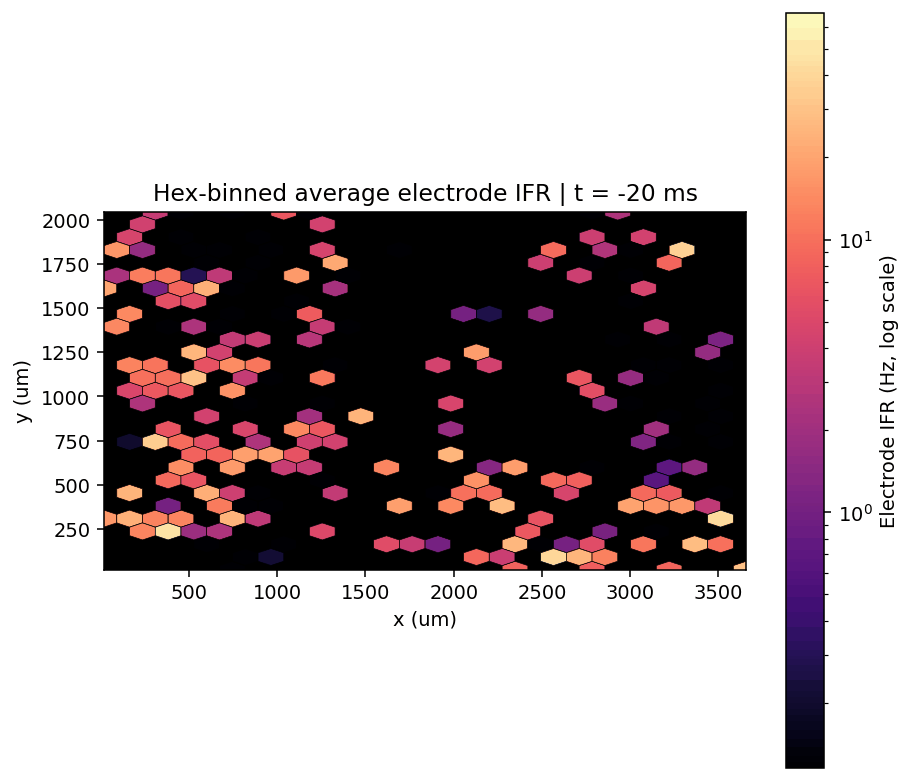

In [454]:
gif_path = repo_root / GIF_OUTPUT_PATH
frame_step = max(1, int(round(GIF_FRAME_STEP_MS / HIGHRES_BIN_MS)))
frame_indices = np.arange(0, len(relative_time_ms), frame_step, dtype=int)
hex_x = layout_df["x"].to_numpy(dtype=float)
hex_y = layout_df["y"].to_numpy(dtype=float)
hex_electrodes = layout_df["electrode"].to_numpy(dtype=int)
hex_idx = np.array([np.flatnonzero(selected_electrodes == int(el))[0] for el in hex_electrodes], dtype=int)

grid_positive = mean_aligned_electrode_rate[mean_aligned_electrode_rate > 0]
grid_vmin = max(1e-2, float(np.quantile(grid_positive, 0.05)))
grid_vmax = max(grid_vmin * 10.0, float(np.quantile(grid_positive, 0.995)))

with imageio.get_writer(gif_path, mode="I", duration=0.14) as writer:
    for time_index in frame_indices:
        values = mean_aligned_electrode_rate[hex_idx, int(time_index)]
        fig, ax = plt.subplots(figsize=(7.4, 7.0))
        hb = ax.hexbin(
            hex_x,
            hex_y,
            C=np.clip(values, grid_vmin, grid_vmax),
            reduce_C_function=np.mean,
            gridsize=HEX_GRID_SIZE,
            cmap="magma",
            mincnt=1,
            linewidths=0.35,
            edgecolors="black",
            norm=LogNorm(vmin=grid_vmin, vmax=grid_vmax),
        )
        ax.set_facecolor("black")
        ax.set_xlim(float(hex_x.min()), float(hex_x.max()))
        ax.set_ylim(float(hex_y.min()), float(hex_y.max()))
        ax.set_xlabel("x (um)")
        ax.set_ylabel("y (um)")
        ax.set_aspect("equal", adjustable="box")
        ax.set_box_aspect((float(hex_y.max()) - float(hex_y.min())) / (float(hex_x.max()) - float(hex_x.min())))
        ax.set_title(f"Hex-binned average electrode IFR | t = {relative_time_ms[time_index]:.0f} ms")
        cbar = fig.colorbar(hb, ax=ax, label="Electrode IFR (Hz, log scale)")
        cbar.locator = LogLocator(base=10)
        cbar.formatter = LogFormatterMathtext(base=10)
        cbar.update_ticks()
        buf = BytesIO()
        fig.savefig(buf, format="png", dpi=140, bbox_inches="tight")
        buf.seek(0)
        writer.append_data(imageio.imread(buf))
        buf.close()
        plt.close(fig)

print(f"Saved GIF to {gif_path}")
display(Image(filename=str(gif_path)))


## Next Step

The notebook now uses nested anchoring, ranks electrodes by peak-window IFR, shows an x-ordered propagation view, and renders a coarse hex-binned gamma-centered GIF. The next useful refinement is to compare this average-array GIF against event-specific GIFs from only the strongest bursts, so that propagation structure is not averaged away.
